# Trump Rally Transcripts — NLP Analysis (Colab-ready v4)

> **v4 fix — topics whose sentences did not match their words.**
> In v3 every sentence contains "Joe / Biden / Sleepy Joe", so the sentence embeddings clustered on *the name and the insult style*, not on the subject.
> The topic words (c-TF-IDF) were computed on cleaned text **without** the name, so they only described a small minority of each cluster
> (e.g. only 16% of the 163 sentences in "Violent mobs" contained any of its top keywords). The optimiser then rewarded this, because c_v only checks
> whether the keywords co-occur somewhere in the rally corpus — never whether they describe the sentences of the topic. Finally, the "typical" sentences sent to
> Flan-T5 were chosen by closeness to the cluster centre, which in a mixed cluster is the most generic "Sleepy Joe..." line, so the summaries and titles drifted.
>
> v4 fixes all four links in that chain: (1) the name and nicknames are masked before embedding, (2) near-empty sentences are dropped,
> (3) the optimiser maximises **c_v × keyword coverage** (share of a topic's sentences that actually contain its keywords), and
> (4) example sentences are chosen by keyword match and summaries/titles are validated against the keywords, with a keyword-based fallback title.

**How to run**
1. *Runtime → Change runtime type → **T4 GPU*** (optional, but the transformer steps run several times faster).
2. *Runtime → **Run all***.
3. When the upload box appears, pick `Trump_Rallies_Dataset.csv`. (If the file is already at `/content/Trump_Rallies_Dataset.csv`, the upload is skipped.)

Set `FAST_MODE = True` in the settings cell for a quicker run with fewer optimisation trials.



## 0. Install packages

In [1]:
%pip install -q bertopic optuna
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 0.1 Imports & settings

In [2]:
import os, re, math, time, random, textwrap, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

HAS_GPU = torch.cuda.is_available()
PIPE_DEVICE = 0 if HAS_GPU else -1
TORCH_DEVICE = "cuda" if HAS_GPU else "cpu"

# ---- user settings --------------------------------------------------------
FAST_MODE = False                  # True -> fewer optimisation trials
N_TRIALS = 15 if FAST_MODE else 40 # trials per joint-search strategy (Random and TPE)
MIN_TOPICS = 6                     # a configuration must produce at least this many topics
MAX_TOPICS = 25                    # ...and at most this many (stops the optimiser splitting into tiny clusters)
MAX_OUTLIER_SHARE = 0.5            # ...and put at most 50% of sentences in the outlier topic (-1)
COVERAGE_TOPN = 5                  # a sentence "fits" its topic if it contains >=1 of the topic's top-N keywords
MIN_CONTENT_WORDS = 3              # sentences with fewer content words (after cleaning) carry no topic -> dropped
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
LABEL_MODEL = "google/flan-t5-large"   # "google/flan-t5-base" is ~3x smaller/faster
DATA_PATH = "/content/Trump_Rallies_Dataset.csv"
# ---------------------------------------------------------------------------

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
print("GPU available:", HAS_GPU)

GPU available: True


## 1. Setup & Data Loading
Loads the 103 rally transcripts (one row per rally: `Place`, `Date`, `Transcript`) and parses the dates so rallies can be ordered chronologically.

In [3]:
# upload the csv only if it isn't there yet
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Please upload Trump_Rallies_Dataset.csv")
        uploaded = files.upload()
        fname = next(iter(uploaded))
        if os.path.abspath(fname) != DATA_PATH:
            os.replace(fname, DATA_PATH)
    except ImportError:
        raise FileNotFoundError(f"Place the CSV at {DATA_PATH} or edit DATA_PATH.")

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")])
df = df.dropna(subset=["Transcript"]).reset_index(drop=True)

df["Date_parsed"] = pd.to_datetime(df["Date"].astype(str).str.strip(), format="%B %d %Y", errors="coerce")
missing = df["Date_parsed"].isna()
if missing.any():
    df.loc[missing, "Date_parsed"] = pd.to_datetime(df.loc[missing, "Date"], errors="coerce")
df["Place_short"] = (df["Place"].astype(str)
                     .str.replace(r"^Speech:\s*Donald Trump Holds a (Campaign )?Rally in\s*", "", regex=True)
                     .str.strip())

texts = df["Transcript"].tolist()
print("Shape:", df.shape, "| unparsed dates:", int(df["Date_parsed"].isna().sum()))
display(df[["Place_short", "Date", "Date_parsed"]].head())

Shape: (103, 5) | unparsed dates: 0


,Place_short,Date,Date_parsed
0,"Sanford, Florida",October 12 2020,2020-10-12
1,"Duluth, Minnesota",September 30 2020,2020-09-30
2,"Middletown, Pennsylvania",September 26 2020,2020-09-26
3,"Newport News, Virginia",September 25 2020,2020-09-25
4,"Jacksonville, Florida",September 24 2020,2020-09-24


## 2. Inspecting a Sample Transcript

In [4]:
IDX = 92 if len(df) > 92 else 0
sample = df.loc[IDX, "Transcript"]
print(f"Transcript {IDX} - {df.loc[IDX, 'Place_short']} ({df.loc[IDX, 'Date']}), {len(sample.split()):,} words\n")
print(textwrap.fill(sample[:3000], 130), "...")

Transcript 92 - Speech: Donald Trump Holds a Political Rally in Pensacola, Florida (December 8 2017), 9,454 words

Thank you. Thank you. [Applause, Crowd chants USA] Thank you, everybody. Thank you. And if you think this crowd is big, you should
see right now what's outside. Congratulations. [Applause] Hello, Pensacola. What a place. Right here on the Emerald Coast, right?
The Emerald Coast in the great state of Florida where we had a tremendous victory, didn't we? Come on. [Applause] We are joined by
many, many people in the military and great American patriots. Thank you very much. [Applause] When you remember the campaign, I
said, let me begin by wishing each and every one of you a very Merry Christmas. Right? [Applause] And I can think of no better
Christmas present for the American people than giving you a massive tax cut. That is what's happening. [Applause] And your Senate
and your House hopefully very shorty will have those approvals. Those heads will go up and you will be payi

## 3. Named Entity Recognition — Who Gets Mentioned
spaCy `en_core_web_sm` extracts PERSON entities from every transcript (run once and reused in Section 4). Stage-direction artefacts such as "Audience Boos" are filtered out.

NER done in 197s


,Entity,Frequency
0,Trump,498
1,Obama,327
2,Biden,303
3,Donald Trump,253
4,Joe,248
5,Joe Biden,193
6,Nancy Pelosi,169
7,Bernie,164
8,Mike,153
9,Hillary,116


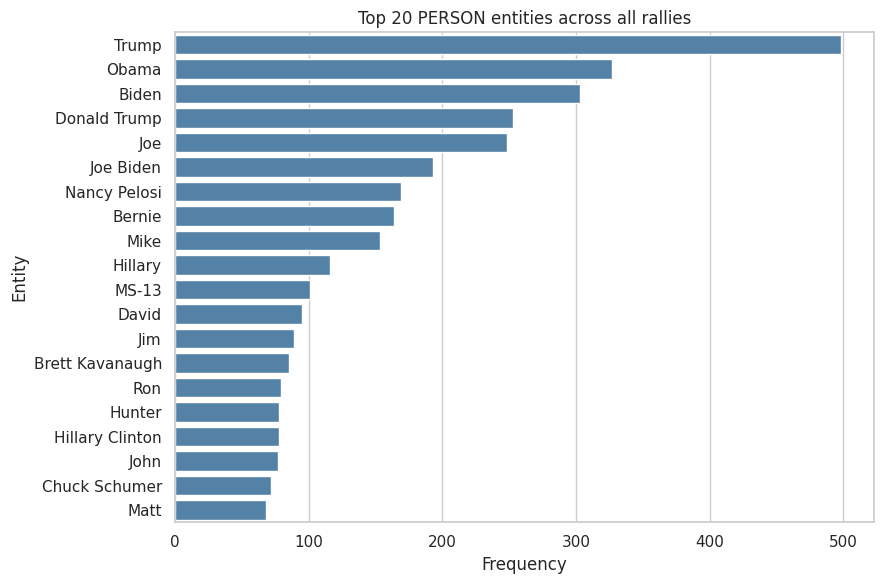

In [5]:
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import en_core_web_sm
    nlp = en_core_web_sm.load()
nlp.max_length = 3_000_000

NOISE = re.compile(r"[\[\]\"]|\baudience\b|\bcrowd\b|applause|\bboos?\b|\bbooing\b|chant|inaudible", re.I)
ner_disable = [p for p in ("tagger", "parser", "attribute_ruler", "lemmatizer") if p in nlp.pipe_names]

t0 = time.time()
persons_per_doc = []
with nlp.select_pipes(disable=ner_disable):
    for doc in nlp.pipe(texts, batch_size=4):
        persons_per_doc.append([e.text.strip() for e in doc.ents
                                if e.label_ == "PERSON" and not NOISE.search(e.text)])
df["persons"] = persons_per_doc
print(f"NER done in {time.time() - t0:.0f}s")

person_counts = Counter(p for plist in persons_per_doc for p in plist)
top_20_person_entities = pd.DataFrame(person_counts.most_common(20), columns=["Entity", "Frequency"])
display(top_20_person_entities)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_20_person_entities, y="Entity", x="Frequency", color="steelblue")
plt.title("Top 20 PERSON entities across all rallies")
plt.tight_layout(); plt.show()

## 4. Tracking Democratic-Figure Mentions Over Time
Fix: the original cell used an undefined `dates` variable. Here the per-rally counts are aligned with the parsed dates, sorted chronologically and split by person so you can see *who* drives the peaks.

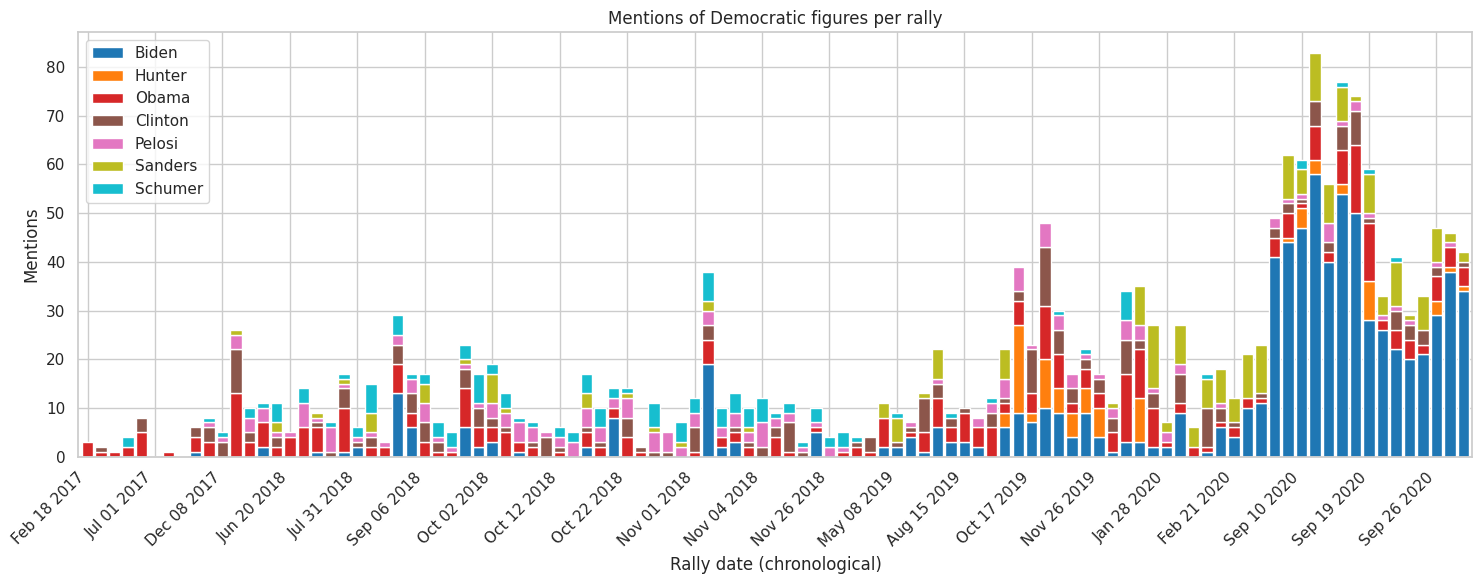

In [6]:
GROUPS = {
    "Biden":   {"Biden", "Joe", "Joe Biden", "Sleepy Joe", "Sleepy Joe Biden"},
    "Hunter":  {"Hunter", "Hunter Biden"},
    "Obama":   {"Obama", "Barack Obama"},
    "Clinton": {"Hillary", "Hillary Clinton", "Clinton"},
    "Pelosi":  {"Nancy Pelosi", "Pelosi"},
    "Sanders": {"Bernie", "Bernie Sanders"},
    "Schumer": {"Chuck Schumer", "Schumer"},
}
name2group = {n: g for g, names in GROUPS.items() for n in names}

rows = []
for i, plist in enumerate(df["persons"]):
    c = Counter(name2group[p] for p in plist if p in name2group)
    rows.append({"Date": df.loc[i, "Date_parsed"], **{g: c.get(g, 0) for g in GROUPS}})
mentions_df = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
mentions_df["Total"] = mentions_df[list(GROUPS)].sum(axis=1)

ax = mentions_df[list(GROUPS)].plot(kind="bar", stacked=True, figsize=(15, 6), width=0.85, colormap="tab10")
# only label every 5th date so the axis stays readable
n = 5
ax.set_xticks(range(0, len(mentions_df), n))
ax.set_xticklabels(mentions_df["Date"].dt.strftime("%b %d %Y").iloc[::n], rotation=45, ha="right")
ax.set_xlabel("Rally date (chronological)"); ax.set_ylabel("Mentions")
ax.set_title("Mentions of Democratic figures per rally")
plt.tight_layout(); plt.show()

## 5. Transcript Similarity (TF-IDF + Cosine Similarity)
Pairwise cosine similarity between all rallies — bright blocks mean reused material. The table lists the most similar pairs.

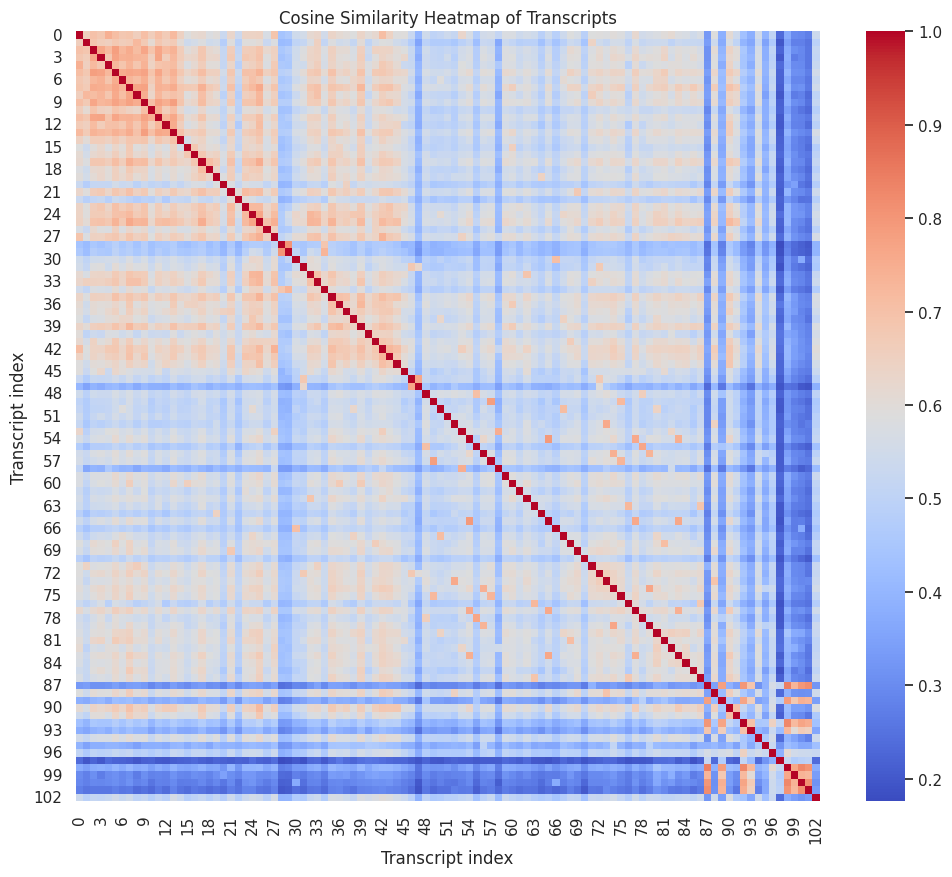

,A,B,cosine,A rally,B rally
0,87,98,0.844,Speech: Donald Trump Holds a Political R (June...,Speech: Donald Trump Holds a Political R (June...
1,98,100,0.827,Speech: Donald Trump Holds a Political R (June...,Speech: Donald Trump Holds a Political R (Marc...
2,92,98,0.827,Speech: Donald Trump Holds a Political R (Dece...,Speech: Donald Trump Holds a Political R (June...
3,87,101,0.817,Speech: Donald Trump Holds a Political R (June...,Speech: Donald Trump Holds a Political R (Marc...
4,100,101,0.811,Speech: Donald Trump Holds a Political R (Marc...,Speech: Donald Trump Holds a Political R (Marc...
5,98,101,0.807,Speech: Donald Trump Holds a Political R (June...,Speech: Donald Trump Holds a Political R (Marc...
6,28,29,0.801,Speech: Donald Trump Holds a Political R (Nove...,Speech: Donald Trump Holds a Political R (Nove...
7,87,100,0.798,Speech: Donald Trump Holds a Political R (June...,Speech: Donald Trump Holds a Political R (Marc...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_matrix = TfidfVectorizer(stop_words="english").fit_transform(texts)
sim = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(sim, cmap="coolwarm")
plt.title("Cosine Similarity Heatmap of Transcripts")
plt.xlabel("Transcript index"); plt.ylabel("Transcript index")
plt.show()

iu = np.triu_indices_from(sim, k=1)
order = np.argsort(sim[iu])[::-1][:8]
pairs = pd.DataFrame({"A": iu[0][order], "B": iu[1][order], "cosine": sim[iu][order].round(3)})
pairs["A rally"] = pairs["A"].map(lambda i: f"{df.Place_short[i][:40]} ({df.Date[i]})")
pairs["B rally"] = pairs["B"].map(lambda i: f"{df.Place_short[i][:40]} ({df.Date[i]})")
display(pairs)

## 6. Extracting Audience / Crowd Reactions
Every bracketed cue is captured with the text before it, then **non-crowd tags such as `[Inaudible]` are removed**. The *Preceding Phrase* is the last two sentences spoken before the reaction (the original kept the whole chunk since the previous tag, which can run to hundreds of words).

In [8]:
TAG_RE = re.compile(r"\[[^\]]+\]")
CROWD_RE = re.compile(r"audience|crowd|applause|cheer|\bboo|chant|laugh|clap|yell|shout|scream", re.I)
SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")

# pair each [tag] with the text that came right before it
def extract_reactions(transcript):
    out, last = [], 0
    for m in TAG_RE.finditer(transcript):
        out.append((transcript[last:m.start()].strip(), m.group(0).strip()))
        last = m.end()
    return out

def last_sentences(text, k=2):
    sents = [s.strip() for s in SENT_SPLIT.split(TAG_RE.sub(" ", text)) if len(s.strip()) > 1]
    return re.sub(r"\s+", " ", " ".join(sents[-k:])).strip()

def reaction_type(tag):
    t = tag.lower()
    if "boo" in t:   return "Boos"
    if "laugh" in t: return "Laughter"
    if "chant" in t: return "Chant"
    if any(x in t for x in ("applause", "cheer", "clap")): return "Applause/Cheers"
    return "Other crowd"

rows = []
for i, tr in enumerate(texts):
    for prec, tag in extract_reactions(tr):
        rows.append({"doc_id": i, "Date": df.loc[i, "Date_parsed"], "Preceding Text": prec, "Crowd Reaction": tag})
reaction_all = pd.DataFrame(rows)

reaction_df = reaction_all[reaction_all["Crowd Reaction"].str.contains(CROWD_RE)].copy()
reaction_df["Preceding Phrase"] = reaction_df["Preceding Text"].apply(last_sentences)
reaction_df = reaction_df[reaction_df["Preceding Phrase"].str.split().str.len() >= 3].reset_index(drop=True)
reaction_df["Reaction Type"] = reaction_df["Crowd Reaction"].apply(reaction_type)

print(f"All bracketed tags: {len(reaction_all):,} | crowd reactions kept: {len(reaction_df):,}")
print(reaction_df["Reaction Type"].value_counts())
display(reaction_df[["Preceding Phrase", "Crowd Reaction", "Reaction Type"]].head())

All bracketed tags: 2,725 | crowd reactions kept: 2,501
Reaction Type
Applause/Cheers    1006
Boos                690
Chant               403
Laughter            239
Other crowd         163
Name: count, dtype: int64


,Preceding Phrase,Crowd Reaction,Reaction Type
0,Thank you. It's great to be back.,"[Audience chants ""USA""]",Chant
1,"It's you know, here we are. But we're going to...","[Audience chants ""We love you""]",Chant
2,We're going to win four more years in the Whit...,"[Audience chants ""USA""]",Chant
3,Most important we've ever had. Biden has made ...,[Audience Boos],Boos
4,"Don't blow it, don't blow it. Sleepy Joe wants...",[Audience Boos],Boos


## 7. Sentiment of Crowd Reactions — SentiWordNet (original method)
Kept for comparison. Scoring the words inside a tag like `[Audience Boos]` with a dictionary is a weak signal, which is why Section 7b adds a transformer model applied to what was actually said.

In [9]:
import nltk
for pkg in ("sentiwordnet", "wordnet", "omw-1.4", "punkt", "punkt_tab"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import sentiwordnet as swn
from nltk.tokenize import word_tokenize

def analyze_sentiment_swn(text):
    score, count = 0.0, 0
    for tok in word_tokenize(re.sub(r"[\[\]\"]", " ", text)):
        syns = list(swn.senti_synsets(tok.lower()))
        if syns:
            score += syns[0].pos_score() - syns[0].neg_score()
            count += 1
    if count == 0:
        return np.nan
    avg = score / count
    return 1 if avg > 0 else (0 if avg < 0 else np.nan)

reaction_df["SWN Label"] = reaction_df["Crowd Reaction"].apply(analyze_sentiment_swn)
print("SentiWordNet label by reaction type (NaN = neutral/unscored):")
display(pd.crosstab(reaction_df["Reaction Type"], reaction_df["SWN Label"].map({1: "positive", 0: "negative"}).fillna("neutral")))

SentiWordNet label by reaction type (NaN = neutral/unscored):


SWN Label,negative,neutral,positive
Reaction Type,,,
Applause/Cheers,1,58,947
Boos,545,145,0
Chant,9,363,31
Laughter,0,239,0
Other crowd,32,97,34


## 7b. Transformer Sentiment of the Speech (Twitter-RoBERTa)
Labels each *Preceding Phrase* as negative / neutral / positive with `cardiffnlp/twitter-roberta-base-sentiment-latest`, then compares that with how the crowd reacted.
This replaces the external `filtered_phrases_nouns_verbs.xlsx`: the same kind of table (`Filtered_phrase` = nouns, proper nouns and verbs of the phrase, `label` = 1 positive / 0 negative) is rebuilt here from the original transcripts.

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Scored 2,501 phrases in 11s


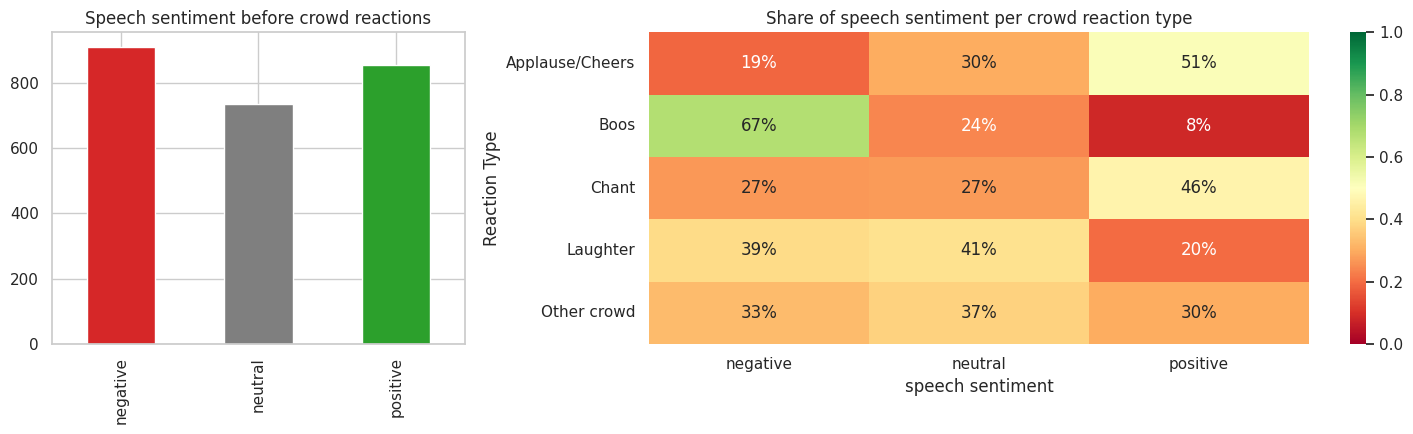

Labelled phrase set: (1736, 11) | positive share: 0.487


,Preceding Phrase,Filtered_phrase,label,Reaction Type
0,Thank you. It's great to be back.,thank,1,Chant
1,"It's you know, here we are. But we're going to...",know going finish going country,1,Chant
2,We're going to win four more years in the Whit...,going win years white house going country,1,Chant
3,Most important we've ever had. Biden has made ...,biden bargain exchange party nomination handed...,0,Boos
4,"Don't blow it, don't blow it. Sleepy Joe wants...",blow blow sleepy joe wants quadruple taxes kno...,0,Boos


In [10]:
from transformers import pipeline

sent_pipe = pipeline("text-classification", model=SENTIMENT_MODEL, tokenizer=SENTIMENT_MODEL, device=PIPE_DEVICE)

def roberta_sentiment(text_list, batch_size=32):
    out = sent_pipe(list(text_list), batch_size=batch_size, truncation=True, max_length=512)
    return [o["label"].lower() for o in out], [float(o["score"]) for o in out]

t0 = time.time()
reaction_df["roberta_label"], reaction_df["roberta_score"] = roberta_sentiment(reaction_df["Preceding Phrase"])
print(f"Scored {len(reaction_df):,} phrases in {time.time() - t0:.0f}s")

order_lab = ["negative", "neutral", "positive"]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2]})
reaction_df["roberta_label"].value_counts().reindex(order_lab).plot(
    kind="bar", ax=axes[0], color=["tab:red", "tab:gray", "tab:green"])
axes[0].set_title("Speech sentiment before crowd reactions"); axes[0].set_xlabel("")
ct = pd.crosstab(reaction_df["Reaction Type"], reaction_df["roberta_label"], normalize="index").reindex(columns=order_lab)
sns.heatmap(ct, annot=True, fmt=".0%", cmap="RdYlGn", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Share of speech sentiment per crowd reaction type"); axes[1].set_xlabel("speech sentiment")
plt.tight_layout(); plt.show()

# Rebuild the 'filtered phrases (nouns & verbs)' dataset from the original transcripts
KEEP_NV = {"NOUN", "PROPN", "VERB"}
filtered = []
for doc in nlp.pipe(reaction_df["Preceding Phrase"].tolist(), batch_size=64):
    filtered.append(" ".join(t.lower_ for t in doc
                             if t.is_alpha and t.pos_ in KEEP_NV and not t.is_stop and len(t) > 1))
reaction_df["Filtered_phrase"] = filtered

df1 = reaction_df[reaction_df["roberta_label"] != "neutral"].copy()
df1["label"] = (df1["roberta_label"] == "positive").astype(int)
df1 = df1[df1["Filtered_phrase"].str.len() > 0].reset_index(drop=True)
print("Labelled phrase set:", df1.shape, "| positive share:", round(df1["label"].mean(), 3))
display(df1[["Preceding Phrase", "Filtered_phrase", "label", "Reaction Type"]].head())

## 8. Feature Importance for Sentiment — Mutual Information
Words are encoded as binary presence (the right input for discrete mutual information). A word counts as "positive" if phrases containing it are positive more often than the overall base rate — computed with exact token matches (the original `str.contains` matched substrings, so `ve` matched almost everything).

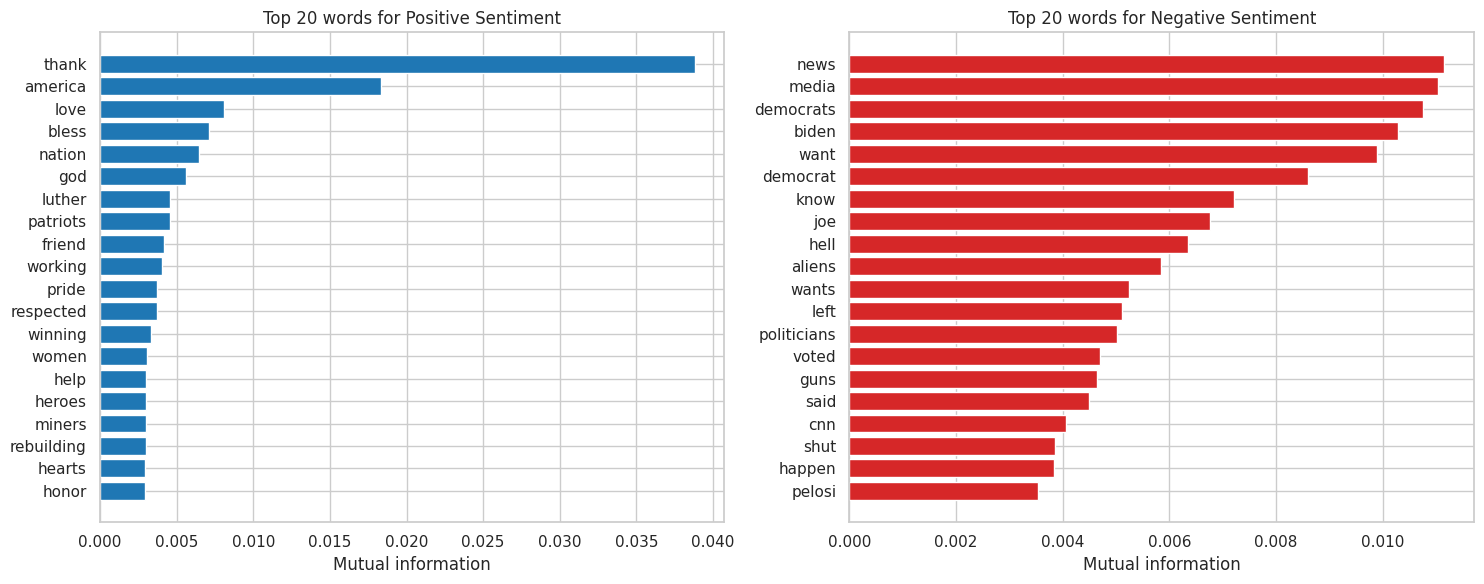

In [11]:
from sklearn.feature_selection import mutual_info_classif, chi2

# share of positive phrases each word shows up in
def word_direction(X, y):
    y = np.asarray(y, dtype=float)
    doc_freq = np.asarray(X.sum(axis=0)).ravel()
    pos = np.asarray(X.T @ y).ravel()
    return pos / np.maximum(doc_freq, 1)

def plot_two(pos, neg, title_pos, title_neg, xlabel):
    h = max(6, 0.28 * max(len(pos), len(neg)))
    fig, axes = plt.subplots(1, 2, figsize=(15, h))
    for ax, feats, color, title in ((axes[0], pos, "tab:blue", title_pos), (axes[1], neg, "tab:red", title_neg)):
        if feats:
            w, s = zip(*feats)
            ax.barh(w, s, color=color)
            ax.invert_yaxis()
        ax.set_title(title); ax.set_xlabel(xlabel)
    plt.tight_layout(); plt.show()

y = df1["label"].values
base_rate = y.mean()

cv_bin = CountVectorizer(binary=True, max_features=1000, min_df=3)
X = cv_bin.fit_transform(df1["Filtered_phrase"])
names = cv_bin.get_feature_names_out()
mi = mutual_info_classif(X, y, discrete_features=True, random_state=SEED)
direction = word_direction(X, y)

top_pos = sorted([(n, s) for n, s, d in zip(names, mi, direction) if d > base_rate], key=lambda x: x[1], reverse=True)[:20]
top_neg = sorted([(n, s) for n, s, d in zip(names, mi, direction) if d < base_rate], key=lambda x: x[1], reverse=True)[:20]
plot_two(top_pos, top_neg, "Top 20 words for Positive Sentiment", "Top 20 words for Negative Sentiment", "Mutual information")

## 9. Feature Importance for Sentiment — Chi-Square Test
Same idea with the original domain-specific stopword list removed first. (Fix: `chi2` is now imported.)

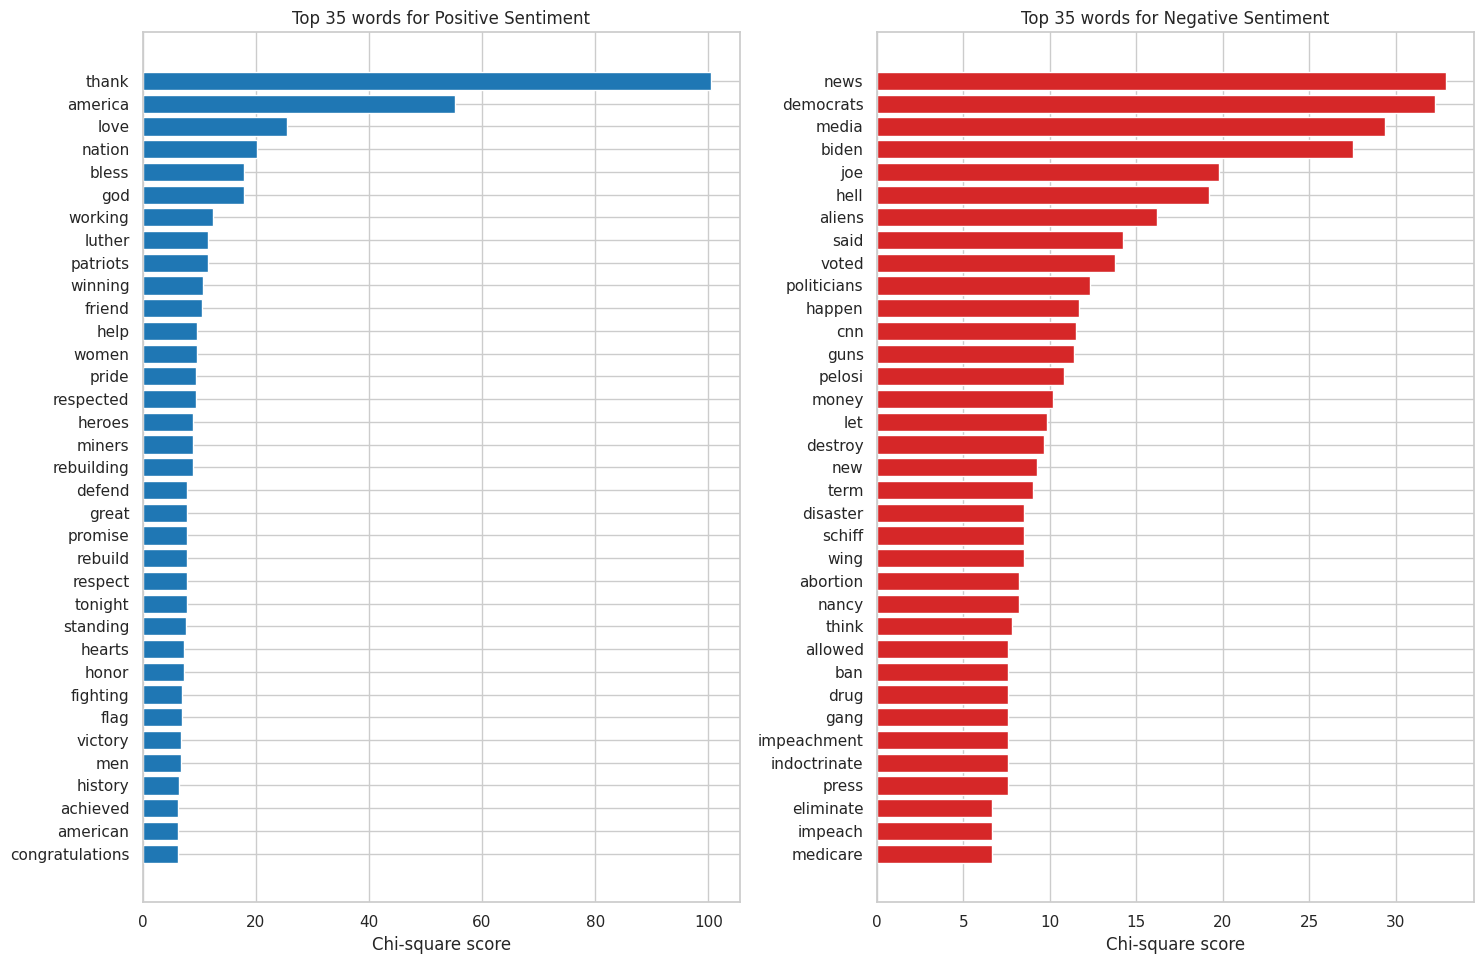

In [12]:
DOMAIN_STOP = {'know', 'want', 'wants', 'supports', 'crooked', 'party', 'straight', 'saw', 'moment',
               'left', 'guys', 'happened', 'idea', 'leader', 'lou', 'lies', 'gets', 'democrat',
               'trying', 'made', 'keep', 'need', 'telling', 'call', 'shut'}

phr = df1["Filtered_phrase"].apply(lambda p: " ".join(w for w in p.split() if w not in DOMAIN_STOP))
cv_chi = CountVectorizer(binary=True, max_features=1000, min_df=3)
X2 = cv_chi.fit_transform(phr)
names2 = cv_chi.get_feature_names_out()
chi2_scores, p_values = chi2(X2, y)
direction2 = word_direction(X2, y)

top_pos = sorted([(n, s) for n, s, d in zip(names2, chi2_scores, direction2) if d > base_rate], key=lambda x: x[1], reverse=True)[:35]
top_neg = sorted([(n, s) for n, s, d in zip(names2, chi2_scores, direction2) if d < base_rate], key=lambda x: x[1], reverse=True)[:35]
plot_two(top_pos, top_neg, "Top 35 words for Positive Sentiment", "Top 35 words for Negative Sentiment", "Chi-square score")

## 10. Extracting Biden-Related Sentences
Keeps every sentence mentioning Biden (bracketed stage directions removed), along with the rally date for the topics-over-time plot. "Joe" only counts when it is **not** followed by another surname (so "Joe Manchin", "Joe Rogan", ... are no longer pulled in).

In [13]:
BIDEN_RE = re.compile(r"\bbiden\b|\bsleepy\s+joe\b", re.I)
# "Joe" on its own (or "Joe Biden"), but not "Joe Manchin", "Joe Rogan", ... (case-sensitive on purpose)
JOE_RE = re.compile(r"\b[Jj]oe\b(?!\s+(?!Biden\b)[A-Z][a-z]+)")

all_biden_sentences, biden_dates = [], []
for i, tr in enumerate(texts):
    for s in SENT_SPLIT.split(TAG_RE.sub(" ", tr)):
        s = re.sub(r"\s+", " ", s).strip()
        if BIDEN_RE.search(s) or JOE_RE.search(s):
            all_biden_sentences.append(s)
            biden_dates.append(df.loc[i, "Date_parsed"])

print(len(all_biden_sentences), "sentences\n")
print("\n".join(all_biden_sentences[:10]))


826 sentences

You know our competitor, sleepy Joe, he had a rally today and practically nobody showed up.
Sleepy Joe, but it's great to be back in my home state, Florida to make my official return to the campaign trail.
Sleepy Joe Biden, not a nice guy, by the way, I have to be honest.
No, Biden had a bad day.
Now Biden had a bad day.
Joe Biden is also owned by the radical globalists, the wealthy donors, the big money special interests who shipped away your jobs, shut down your factories, threw open your borders, and ravaged your cities while sacrificing American blood and treasure in this ridiculous -- endless wars, set of endless wars that we've been in for a long time, 19 years.
Biden has made a corrupt bargain exchange for his party's nomination, he's handed control to the Socialists, the Marxists, and the left-wing extremists and you know that and he's got no strength left, he's got no power left.
Sleepy Joe wants to quadruple your taxes, you know, wants to quadruple.
And by the 

## 11. Topic Modeling Preparation
- **Why the topics did not match their words before:** every sentence here mentions Biden, so a sentence encoder sees "Sleepy Joe Biden ..." as the dominant signal and clusters by *who / which insult*, not by *what about*. The keywords, however, come from the cleaned text in which `joe`/`biden` are removed. The two views disagreed, so each cluster was a mix and its keywords only fitted a minority of it.
- **Fix 1 — mask the name for embeddings:** `DOCS_EMB` is the original sentence with "Biden", "Joe", "Sleepy Joe", "Biden's"... replaced by *he / his*, and filler ("you know", "by the way", "OK") removed. The encoder now has to use the subject of the sentence.
- **Fix 2 — drop content-free sentences:** after cleaning (nouns/verbs/adjectives/adverbs, custom stopwords), sentences with fewer than `MIN_CONTENT_WORDS` words ("Biden had a bad day", "I sent him a note, dear Joe") are dropped; they have no topic and only blur clusters.
- `DOCS` (cleaned) is still used for the topic words; `DOCS_ORIG` (untouched) is used for display, sentiment and summaries.
- **Coherence (c_v)** is computed against a reference corpus of all full transcripts, with the standard c_v definition (boolean sliding window of 110 tokens, NPMI, indirect cosine). It is implemented directly in NumPy so no `gensim` install is needed. `c_npmi` (window 10) is reported as a second opinion.

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

CUSTOM_STOP = {
    "said", "think", "got", "let", "like", "did", "going", "remember", "know",
    "compared", "months", "day", "thing", "people", "bad", "right", "can", "joe",
    "biden", "had", "now", "say", "go", "gon", "just", "have", "here", "so", "do", "get", "as",
    "need", "done", "then", "sleepy", "okay", "ok", "way", "want", "wants", "look", "tell"}
KEEP_POS = {"NOUN", "VERB", "ADJ", "ADV"}

# --- text for the EMBEDDINGS: original sentence with the name/nicknames neutralised -------------
_NICK = r"(?:(?:sleepy|slow|crooked|creepy)\s+)?"
NAME_POSS_RE = re.compile(rf"\b{_NICK}(?:joe\s+)?biden['’]s\b|\b{_NICK}joe['’]s\b", re.I)
NAME_RE      = re.compile(rf"\b{_NICK}(?:joe\s+)?biden\b|\b{_NICK}joe\b", re.I)
FILLER_RE    = re.compile(r"\b(?:you know|by the way|believe me|let me tell you|I have to be honest|OK|okay)\b[,.]?\s*", re.I)

def mask_name(s):
    s = NAME_POSS_RE.sub("his", s)
    s = NAME_RE.sub("he", s)
    s = FILLER_RE.sub("", s)
    s = re.sub(r"\s*--\s*", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\s+([,.?!])", r"\1", s)
    s = re.sub(r",\s*([.?!])", r"\1", s).strip(" ,")
    return s[:1].upper() + s[1:]

# --- text for the TOPIC WORDS (c-TF-IDF): content words only ------------------------------------
cleaned = []
for doc in nlp.pipe(all_biden_sentences, batch_size=64):
    cleaned.append(" ".join(t.lower_ for t in doc
                            if t.is_alpha and t.pos_ in KEEP_POS and t.lower_ not in CUSTOM_STOP and not t.is_stop))

keep = [i for i, c in enumerate(cleaned) if len(c.split()) >= MIN_CONTENT_WORDS]
DOCS       = [cleaned[i] for i in keep]                         # topic words (c-TF-IDF)
DOCS_ORIG  = [all_biden_sentences[i] for i in keep]             # display, sentiment, summaries
DOCS_EMB   = [mask_name(all_biden_sentences[i]) for i in keep]  # embeddings (name masked)
DOCS_DATES = [biden_dates[i] for i in keep]
DOC_TOKENS = [set(d.split()) for d in DOCS]                     # for keyword-coverage checks
print(f"{len(DOCS)} of {len(cleaned)} sentences kept for topic modeling\n")
for o, m in list(zip(DOCS_ORIG, DOCS_EMB))[:4]:
    print("original:", o, "\nembedded:", m, "\n")


539 of 826 sentences kept for topic modeling

original: You know our competitor, sleepy Joe, he had a rally today and practically nobody showed up. 
embedded: Our competitor, he, he had a rally today and practically nobody showed up. 

original: Sleepy Joe, but it's great to be back in my home state, Florida to make my official return to the campaign trail. 
embedded: He, but it's great to be back in my home state, Florida to make my official return to the campaign trail. 

original: Sleepy Joe Biden, not a nice guy, by the way, I have to be honest. 
embedded: He, not a nice guy 

original: Joe Biden is also owned by the radical globalists, the wealthy donors, the big money special interests who shipped away your jobs, shut down your factories, threw open your borders, and ravaged your cities while sacrificing American blood and treasure in this ridiculous -- endless wars, set of endless wars that we've been in for a long time, 19 years. 
embedded: He is also owned by the radical globa

In [15]:
class Coherence:
    # c_v / c_npmi topic coherence over a tokenised reference corpus (boolean sliding windows).
    def __init__(self, token_docs, window, stride=1, cache_size=2500):
        vocab, ids, starts, ends, offset = {}, [], [], [], 0
        for toks in token_docs:
            L = len(toks)
            if L == 0:
                continue
            ids.extend(vocab.setdefault(w, len(vocab)) for w in toks)
            s = np.array([0]) if L <= window else np.arange(0, L - window + 1, stride)
            starts.append(s + offset)
            ends.append(np.minimum(s + window, L) + offset)
            offset += L
        ids = np.asarray(ids)
        self.order = np.argsort(ids, kind="stable")              # token positions grouped by word id
        self.bounds = np.searchsorted(ids[self.order], np.arange(len(vocab) + 1))
        self.vocab, self.starts, self.ends = vocab, np.concatenate(starts), np.concatenate(ends)
        self.n = len(self.starts)
        self._cache, self._cache_size = {}, cache_size

    def presence(self, w):
        if w in self._cache:
            return self._cache[w]
        wid = self.vocab.get(w)
        v = None
        if wid is not None:
            pos = self.order[self.bounds[wid]:self.bounds[wid + 1]]
            v = (np.searchsorted(pos, self.ends) - np.searchsorted(pos, self.starts)) > 0
        if len(self._cache) < self._cache_size:
            self._cache[w] = v
        return v

    def score_topic(self, words, measure="c_v"):
        P = [self.presence(w) for w in words]
        P = [p for p in P if p is not None and p.any()]
        if len(P) < 2:
            return np.nan
        M = np.vstack(P).astype(np.float32)
        p = M.mean(axis=1)
        joint = (M @ M.T) / self.n
        eps = 1e-12
        npmi = np.log((joint + eps) / np.outer(p, p)) / -np.log(joint + eps)
        if measure == "c_v":
            s = npmi.sum(axis=0)
            cos = (npmi @ s) / (np.linalg.norm(npmi, axis=1) * np.linalg.norm(s) + eps)
            return float(cos.mean())
        iu = np.triu_indices(len(P), k=1)
        return float(npmi[iu].mean())

REF_STOP = set(ENGLISH_STOP_WORDS) | CUSTOM_STOP
def ref_tokens(text):
    text = TAG_RE.sub(" ", text).lower()
    return [w for w in re.findall(r"[a-z]+", text) if w not in REF_STOP and len(w) > 1]

ref_docs = [ref_tokens(t) for t in texts]
CV = Coherence(ref_docs, window=110, stride=10)   # c_v   (stride 10 keeps memory low; near-identical to stride 1)
NP = Coherence(ref_docs, window=10, stride=5)     # c_npmi
print(f"Reference corpus: {sum(map(len, ref_docs)):,} tokens | c_v windows: {CV.n:,} | npmi windows: {NP.n:,}")
print("Sanity check  c_v(tax, taxes, cut, cuts, income) =", round(CV.score_topic(["tax", "taxes", "cut", "cuts", "income"]), 3))
print("              c_v(tax, military, beautiful, china, vote) =", round(CV.score_topic(["tax", "military", "beautiful", "china", "vote"]), 3))

Reference corpus: 338,439 tokens | c_v windows: 32,774 | npmi windows: 67,543
Sanity check  c_v(tax, taxes, cut, cuts, income) = 0.817
              c_v(tax, military, beautiful, china, vote) = 0.383


### 11.1 Sentence embeddings (computed once, reused by every experiment)
Three free sentence-transformer models × two inputs: the **masked** sentence (name and nicknames replaced by he/his — see above) and the cleaned text. The unmasked raw sentence is no longer used, because the repeated name dominated the embeddings.

In [16]:
from sentence_transformers import SentenceTransformer

EMB_MODELS = {
    "mpnet":     "sentence-transformers/all-mpnet-base-v2",
    "minilm":    "sentence-transformers/all-MiniLM-L6-v2",
    "bge-small": "BAAI/bge-small-en-v1.5",
}
ST, EMB = {}, {}
t0 = time.time()
for short, name in EMB_MODELS.items():
    ST[short] = SentenceTransformer(name, device=TORCH_DEVICE)
    for inp, data in (("masked", DOCS_EMB), ("cleaned", DOCS)):
        EMB[f"{short}|{inp}"] = ST[short].encode(data, batch_size=64, show_progress_bar=False,
                                                 normalize_embeddings=True)
print(f"{len(EMB)} embedding sets in {time.time() - t0:.0f}s:", list(EMB))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

6 embedding sets in 20s: ['mpnet|masked', 'mpnet|cleaned', 'minilm|masked', 'minilm|cleaned', 'bge-small|masked', 'bge-small|cleaned']


### 11.2 BERTopic experiment helpers
Every fit is logged with its configuration, c_v, c_npmi, topic diversity, **keyword coverage**, number of topics and outlier share.

**Keyword coverage** = share of a topic's sentences that contain at least one of the topic's top `COVERAGE_TOPN` keywords (size-weighted over topics). It measures what c_v cannot: whether the keywords actually describe the sentences of the topic. v3 selected a model with c_v 0.54 whose biggest topics had only 16–23% coverage.

The optimisation target is now **`fit = c_v × coverage`**. A configuration is **valid** only if it yields between `MIN_TOPICS` and `MAX_TOPICS` topics and at most `MAX_OUTLIER_SHARE` outliers.

In [17]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP
from hdbscan import HDBSCAN

BASE_CFG = dict(emb="mpnet|masked", n_neighbors=15, n_components=5, min_cluster_size=10, min_samples=None,
                method="eom", ngram_max=1, reduce_frequent_words=False, bm25=False, nr_topics=None)
LOG = []

def build_model(c, seed=SEED, representation_model=None, embedding_model=None):
    ms = c["min_samples"]
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=int(c["n_neighbors"]), n_components=int(c["n_components"]),
                        min_dist=0.0, metric="cosine", random_state=seed),
        hdbscan_model=HDBSCAN(min_cluster_size=int(c["min_cluster_size"]),
                              min_samples=None if ms is None else int(ms),
                              metric="euclidean", cluster_selection_method=c["method"], prediction_data=True),
        vectorizer_model=CountVectorizer(ngram_range=(1, int(c["ngram_max"])), stop_words="english", min_df=2),
        ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=c["reduce_frequent_words"], bm25_weighting=c["bm25"]),
        representation_model=representation_model,
        nr_topics=c["nr_topics"], top_n_words=10, verbose=False)

def topic_word_lists(model, aspect=None, topn=10):
    topics = model.get_topics() if aspect is None else model.topic_aspects_[aspect]
    res = {}
    for tid, ws in topics.items():
        if tid == -1:
            continue
        toks = []
        for w, _ in ws:
            for t in str(w).split():          # split n-grams into unigrams for scoring
                if t and t not in toks:
                    toks.append(t)
        if toks:
            res[tid] = toks[:topn]
    return res

def keyword_coverage(model, tw, topn=COVERAGE_TOPN):
    """Per topic: share of its sentences containing >=1 of its top-n keywords."""
    topics = np.asarray(model.topics_)
    cov = {}
    for t, words in tw.items():
        idx = np.where(topics == t)[0]
        if len(idx) == 0:
            continue
        ws = set(words[:topn])
        cov[t] = float(np.mean([bool(DOC_TOKENS[i] & ws) for i in idx]))
    return cov

def evaluate(model, aspect=None):
    tw = topic_word_lists(model, aspect)
    cv_per = {t: CV.score_topic(w, "c_v") for t, w in tw.items()}
    np_per = {t: NP.score_topic(w, "c_npmi") for t, w in tw.items()}
    cov_per = keyword_coverage(model, tw)
    sizes = pd.Series(np.asarray(model.topics_)).value_counts()
    tot = sum(sizes.get(t, 0) for t in cov_per)
    words = [w for ws in tw.values() for w in ws]
    m = dict(n_topics=len(tw),
             c_v=np.nanmean(list(cv_per.values())) if tw else np.nan,
             c_npmi=np.nanmean(list(np_per.values())) if tw else np.nan,
             diversity=len(set(words)) / max(1, len(words)),
             coverage=(sum(cov_per[t] * sizes.get(t, 0) for t in cov_per) / tot) if tot else np.nan,
             min_coverage=min(cov_per.values()) if cov_per else np.nan,
             outlier_pct=float(np.mean(np.asarray(model.topics_) == -1)),
             cv_per_topic=cv_per, cov_per_topic=cov_per)
    m["fit"] = m["c_v"] * m["coverage"]          # coherent words AND words that describe the sentences
    valid = (MIN_TOPICS <= m["n_topics"] <= MAX_TOPICS and m["outlier_pct"] <= MAX_OUTLIER_SHARE
             and not np.isnan(m["fit"]))
    m["score"] = m["fit"] if valid else np.nan
    return m

def run_config(overrides, stage, base=None, seed=SEED, keep_model=False, verbose=True):
    cfg = {**BASE_CFG, **(base or {}), **overrides}
    model = build_model(cfg, seed)
    t0 = time.time()
    try:
        model.fit(DOCS, embeddings=EMB[cfg["emb"]])
        m = evaluate(model)
    except Exception as e:
        print(f"  [{stage}] fit failed: {e}")
        m = dict(n_topics=0, c_v=np.nan, c_npmi=np.nan, diversity=np.nan, coverage=np.nan,
                 min_coverage=np.nan, outlier_pct=np.nan, fit=np.nan, score=np.nan)
    rec = {"stage": stage, "seed": seed, "cfg": dict(cfg), **cfg,
           **{k: v for k, v in m.items() if k not in ("cv_per_topic", "cov_per_topic")}, "seconds": time.time() - t0}
    LOG.append(rec)
    if verbose:
        flag = "" if not np.isnan(rec["score"]) else "  (fails constraints)"
        print(f"  [{stage}] fit={rec['fit']:.3f}  c_v={rec['c_v']:.3f}  coverage={rec['coverage']:.0%}  topics={rec['n_topics']:>2}  "
              f"outliers={rec['outlier_pct']:.0%}{flag}")
    return (model if keep_model else None), rec

def best_record(stages=None, exclude=("G Stability",)):
    recs = [r for r in LOG if (stages is None or r["stage"] in stages) and r["stage"] not in exclude]
    pool = [r for r in recs if not np.isnan(r["score"])] or [r for r in recs if not np.isnan(r["fit"])]
    if not pool:
        raise RuntimeError("No successful BERTopic fit in these stages.")
    return max(pool, key=lambda r: r["score"] if not np.isnan(r["score"]) else r["fit"])

def stage_df(stage):
    return pd.DataFrame([r for r in LOG if r["stage"] == stage])

## 12. BERTopic Optimisation (target: c_v × keyword coverage)

Stages A–E are a **coordinate-descent** search: each stage tunes one group of settings and passes its winner on. Stage F runs a **joint search** over everything at once, comparing **Random search** with **Bayesian optimisation (Optuna TPE)**. Stage G checks that the winner is stable across random seeds.

### Baseline — the original notebook's setup
`all-mpnet-base-v2` on the cleaned text, BERTopic defaults (now also scored with keyword coverage).

In [18]:
_, baseline = run_config({"emb": "mpnet|cleaned"}, stage="0 Baseline")

  [0 Baseline] fit=0.266  c_v=0.483  coverage=55%  topics=10  outliers=35%


### Stage A — embedding model & input text

  [A Embedding] fit=0.215  c_v=0.429  coverage=50%  topics=10  outliers=22%
  [A Embedding] fit=0.266  c_v=0.483  coverage=55%  topics=10  outliers=35%
  [A Embedding] fit=0.253  c_v=0.450  coverage=56%  topics=11  outliers=25%
  [A Embedding] fit=0.309  c_v=0.476  coverage=65%  topics=14  outliers=34%
  [A Embedding] fit=0.268  c_v=0.510  coverage=53%  topics=10  outliers=33%
  [A Embedding] fit=0.286  c_v=0.477  coverage=60%  topics=11  outliers=36%


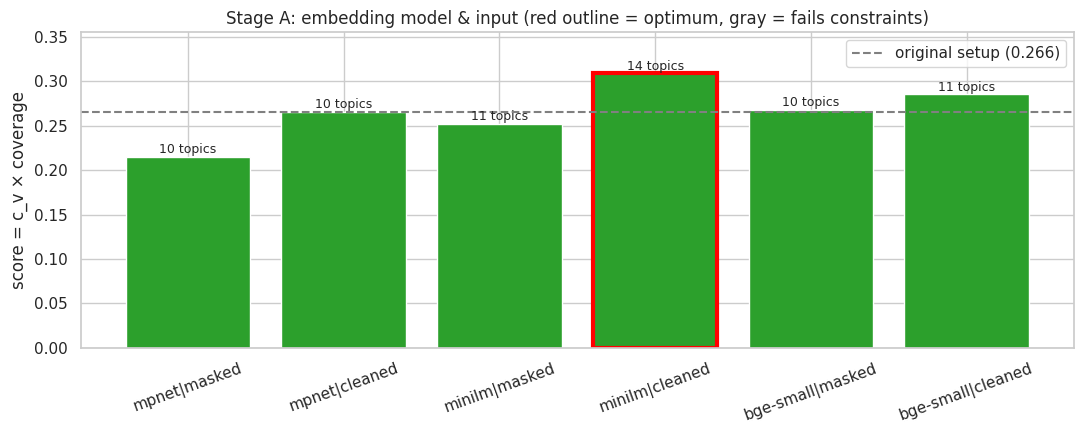

Best embedding: minilm|cleaned


In [19]:
for k in EMB:
    run_config({"emb": k}, stage="A Embedding")

a = stage_df("A Embedding")
best_a = best_record(["A Embedding"])
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["tab:green" if not np.isnan(s) else "lightgray" for s in a["score"]]
bars = ax.bar(a["emb"], np.nan_to_num(a["fit"]), color=colors)
for b, n_t, e in zip(bars, a["n_topics"], a["emb"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.004, f"{n_t} topics", ha="center", fontsize=9)
    if e == best_a["emb"]:
        b.set_edgecolor("red"); b.set_linewidth(3)
ax.axhline(baseline["fit"], ls="--", color="gray", label=f"original setup ({baseline['fit']:.3f})")
ax.set_ylabel("score = c_v × coverage"); ax.set_ylim(0, max(np.nan_to_num(a["fit"])) * 1.15)
ax.set_title("Stage A: embedding model & input (red outline = optimum, gray = fails constraints)")
ax.legend(); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
print("Best embedding:", best_a["emb"])

### Stage B — HDBSCAN `min_cluster_size` grid

  [B HDBSCAN min_cluster_size] fit=0.320  c_v=0.469  coverage=68%  topics=29  outliers=18%  (fails constraints)
  [B HDBSCAN min_cluster_size] fit=0.316  c_v=0.485  coverage=65%  topics=17  outliers=24%
  [B HDBSCAN min_cluster_size] fit=0.309  c_v=0.476  coverage=65%  topics=14  outliers=34%
  [B HDBSCAN min_cluster_size] fit=0.283  c_v=0.482  coverage=59%  topics=10  outliers=35%
  [B HDBSCAN min_cluster_size] fit=0.256  c_v=0.485  coverage=53%  topics= 7  outliers=35%
  [B HDBSCAN min_cluster_size] fit=0.253  c_v=0.546  coverage=46%  topics= 5  outliers=36%  (fails constraints)
  [B HDBSCAN min_cluster_size] fit=0.257  c_v=0.531  coverage=48%  topics= 4  outliers=44%  (fails constraints)
  [B HDBSCAN min_cluster_size] fit=0.159  c_v=0.491  coverage=32%  topics= 2  outliers=17%  (fails constraints)
  [B HDBSCAN min_cluster_size] fit=0.170  c_v=0.497  coverage=34%  topics= 2  outliers=23%  (fails constraints)


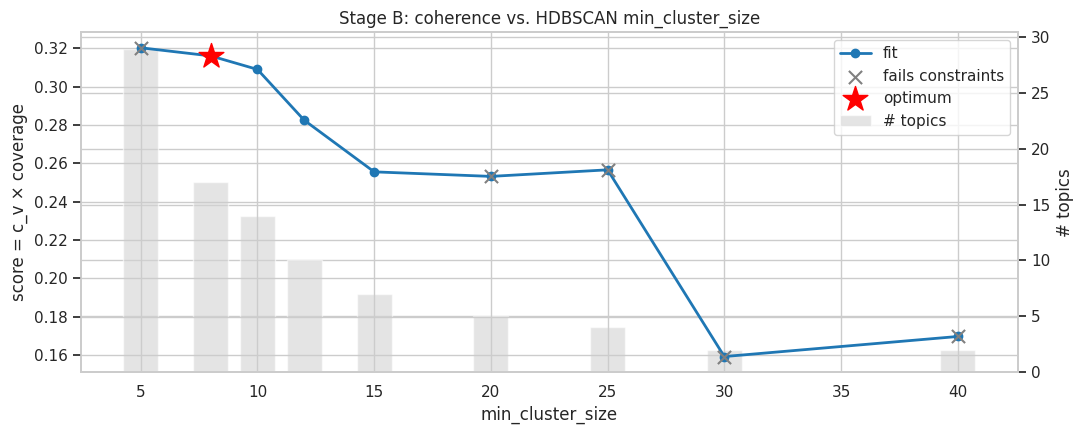

In [20]:
cur = best_a["cfg"]
for mcs in [5, 8, 10, 12, 15, 20, 25, 30, 40]:
    run_config({"min_cluster_size": mcs}, stage="B HDBSCAN min_cluster_size", base=cur)

b = stage_df("B HDBSCAN min_cluster_size").sort_values("min_cluster_size")
best_b = best_record(["B HDBSCAN min_cluster_size"])
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()
ax2.bar(b["min_cluster_size"], b["n_topics"], width=1.5, color="lightgray", alpha=0.6, label="# topics")
ax1.plot(b["min_cluster_size"], b["fit"], "o-", color="tab:blue", lw=2, label="fit")
invalid = b[b["score"].isna()]
ax1.scatter(invalid["min_cluster_size"], invalid["fit"], marker="x", s=90, color="gray", zorder=5, label="fails constraints")
ax1.scatter([best_b["min_cluster_size"]], [best_b["fit"]], marker="*", s=350, color="red", zorder=6, label="optimum")
ax1.set_zorder(ax2.get_zorder() + 1); ax1.patch.set_visible(False)
ax1.set_xlabel("min_cluster_size"); ax1.set_ylabel("score = c_v × coverage"); ax2.set_ylabel("# topics")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="best")
ax1.set_title("Stage B: coherence vs. HDBSCAN min_cluster_size")
plt.tight_layout(); plt.show()

### Stage C — UMAP `n_neighbors` × `n_components` grid

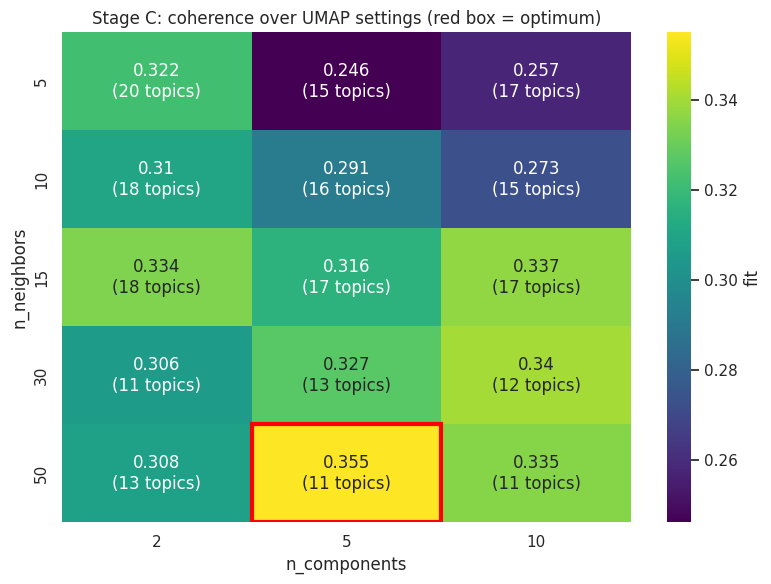

Best UMAP: n_neighbors=50, n_components=5, fit=0.355 (c_v 0.523, coverage 68%)


In [21]:
cur = best_b["cfg"]
for nn in [5, 10, 15, 30, 50]:
    for nc in [2, 5, 10]:
        run_config({"n_neighbors": nn, "n_components": nc}, stage="C UMAP grid", base=cur, verbose=False)

c = stage_df("C UMAP grid")
best_c = best_record(["C UMAP grid"])
piv = c.pivot_table(index="n_neighbors", columns="n_components", values="score", dropna=False)
piv_n = c.pivot_table(index="n_neighbors", columns="n_components", values="n_topics", dropna=False).fillna(0)
annot = piv.round(3).astype(str) + "\n(" + piv_n.astype(int).astype(str) + " topics)"
annot = annot.where(piv.notna(), "fails")
plt.figure(figsize=(8, 6))
ax = sns.heatmap(piv, annot=annot, fmt="", cmap="viridis", cbar_kws={"label": "fit"})
r_i = list(piv.index).index(best_c["n_neighbors"]); c_i = list(piv.columns).index(best_c["n_components"])
ax.add_patch(plt.Rectangle((c_i, r_i), 1, 1, fill=False, edgecolor="red", lw=3))
ax.set_title("Stage C: coherence over UMAP settings (red box = optimum)")
plt.tight_layout(); plt.show()
print(f"Best UMAP: n_neighbors={best_c['n_neighbors']}, n_components={best_c['n_components']}, "
      f"fit={best_c['fit']:.3f} (c_v {best_c['c_v']:.3f}, coverage {best_c['coverage']:.0%})")

### Stage D — topic-word extraction (c-TF-IDF variants & n-grams)

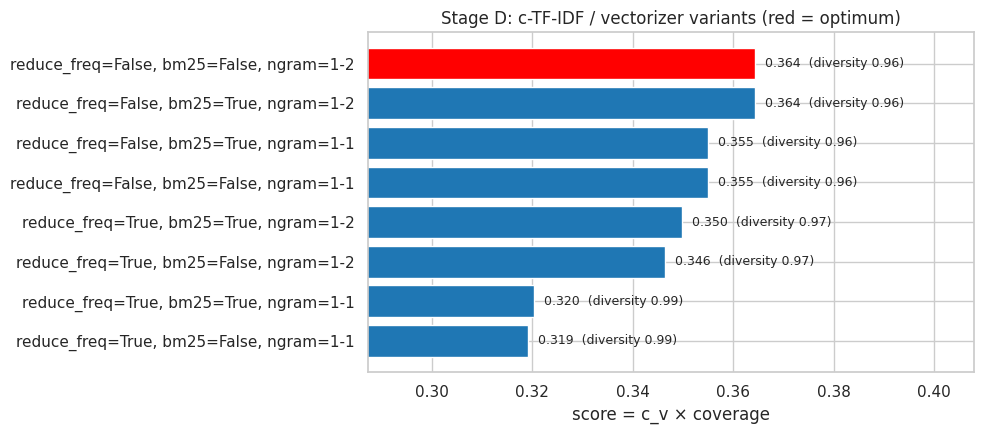

In [22]:
cur = best_c["cfg"]
for rfw in (False, True):
    for bm25 in (False, True):
        for ng in (1, 2):
            run_config({"reduce_frequent_words": rfw, "bm25": bm25, "ngram_max": ng},
                       stage="D c-TF-IDF variants", base=cur, verbose=False)

d = stage_df("D c-TF-IDF variants")
d["variant"] = d.apply(lambda r: f"reduce_freq={r.reduce_frequent_words}, bm25={r.bm25}, ngram=1-{r.ngram_max}", axis=1)
d = d.sort_values("fit")
best_d = best_record(["D c-TF-IDF variants"])
fig, ax = plt.subplots(figsize=(10, 4.5))
cols = ["red" if (r.reduce_frequent_words == best_d["reduce_frequent_words"] and r.bm25 == best_d["bm25"]
                  and r.ngram_max == best_d["ngram_max"]) else "tab:blue" for r in d.itertuples()]
ax.barh(d["variant"], d["fit"], color=cols)
for y_, (v, dv) in enumerate(zip(d["fit"], d["diversity"])):
    ax.text(v + 0.002, y_, f"{v:.3f}  (diversity {dv:.2f})", va="center", fontsize=9)  # v = fit
ax.set_xlim(d["fit"].min() * 0.9, d["fit"].max() * 1.12)
ax.set_xlabel("score = c_v × coverage"); ax.set_title("Stage D: c-TF-IDF / vectorizer variants (red = optimum)")
plt.tight_layout(); plt.show()

### Stage E — topic reduction (`nr_topics`)
Merging similar topics can raise or lower coherence; this sweep finds out which.

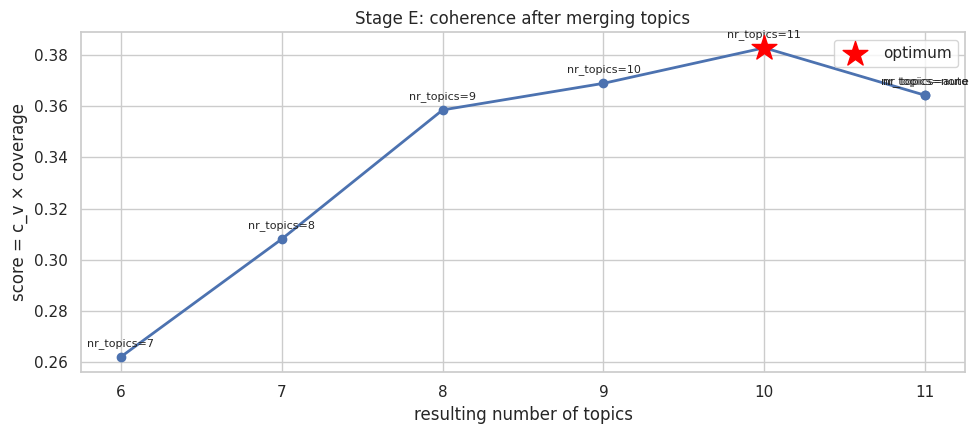

In [23]:
cur = best_d["cfg"]
n_base = int(best_d["n_topics"])
targets = [None, "auto"]
if n_base - 1 > MIN_TOPICS:
    targets += sorted(set(np.linspace(MIN_TOPICS + 1, n_base, 6).astype(int).tolist()))
for k in targets:
    run_config({"nr_topics": k}, stage="E Topic reduction", base=cur, verbose=False)

e = stage_df("E Topic reduction")
best_e = best_record(["E Topic reduction"])
e["setting"] = e["nr_topics"].apply(lambda v: "none" if v is None or (isinstance(v, float) and np.isnan(v)) else str(v))
e_s = e.sort_values("n_topics")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(e_s["n_topics"], e_s["fit"], "o-", lw=2)
for r in e_s.itertuples():
    ax.annotate(f"nr_topics={r.setting}", (r.n_topics, r.fit), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.scatter([best_e["n_topics"]], [best_e["fit"]], marker="*", s=350, color="red", zorder=5, label="optimum")
ax.set_xlabel("resulting number of topics"); ax.set_ylabel("score = c_v × coverage")
ax.set_title("Stage E: coherence after merging topics"); ax.legend()
plt.tight_layout(); plt.show()

### Stage F — joint search: Random search vs. Bayesian optimisation (Optuna TPE)
Both search all settings at once (embedding, UMAP, HDBSCAN incl. `min_samples` and `leaf` selection, c-TF-IDF options, n-grams) with the same budget of `N_TRIALS` fits.

In [24]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(stage):
    def objective(trial):
        mcs = trial.suggest_int("min_cluster_size", 5, 40)
        cfg = dict(
            emb=trial.suggest_categorical("emb", list(EMB)),
            n_neighbors=trial.suggest_int("n_neighbors", 5, 60),
            n_components=trial.suggest_int("n_components", 2, 15),
            min_cluster_size=mcs,
            min_samples=trial.suggest_int("min_samples", 1, mcs),
            method=trial.suggest_categorical("method", ["eom", "leaf"]),
            ngram_max=trial.suggest_int("ngram_max", 1, 2),
            reduce_frequent_words=trial.suggest_categorical("reduce_frequent_words", [False, True]),
            bm25=trial.suggest_categorical("bm25", [False, True]),
            nr_topics=None)
        _, rec = run_config(cfg, stage, verbose=False)
        if (trial.number + 1) % 10 == 0:
            print(f"  {stage}: trial {trial.number + 1}/{N_TRIALS}")
        return 0.0 if np.isnan(rec["score"]) else rec["score"]
    return objective

t0 = time.time()
study_rand = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=SEED))
study_rand.optimize(make_objective("F Random search"), n_trials=N_TRIALS)
study_tpe = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=8, multivariate=True))
study_tpe.optimize(make_objective("F Bayesian (TPE)"), n_trials=N_TRIALS)
print(f"Joint search done in {time.time() - t0:.0f}s | best random={study_rand.best_value:.3f} | best TPE={study_tpe.best_value:.3f}")

  F Random search: trial 10/40
  F Random search: trial 20/40
  F Random search: trial 30/40
  F Random search: trial 40/40
  F Bayesian (TPE): trial 10/40
  F Bayesian (TPE): trial 20/40
  F Bayesian (TPE): trial 30/40
  F Bayesian (TPE): trial 40/40
Joint search done in 165s | best random=0.343 | best TPE=0.343


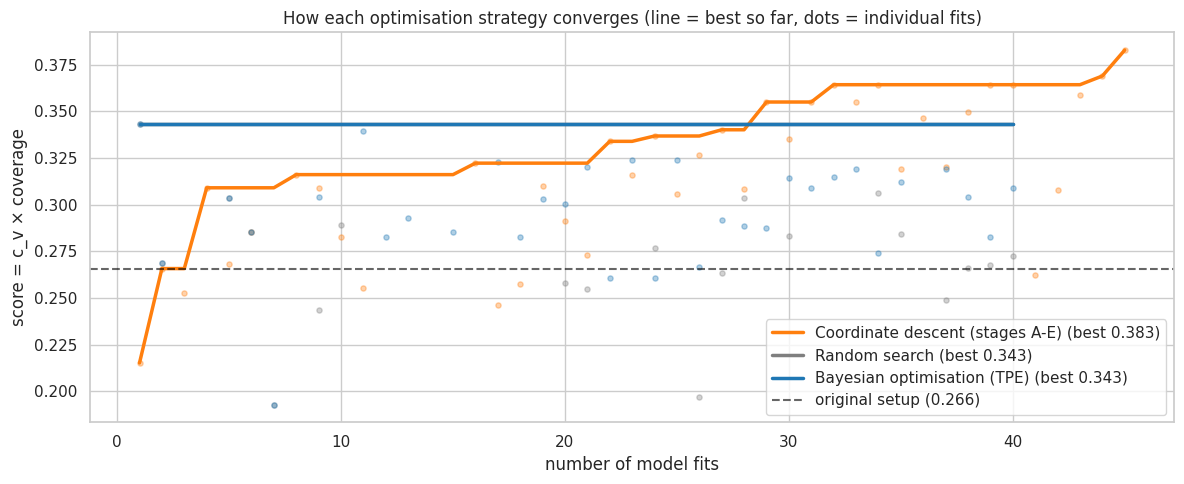

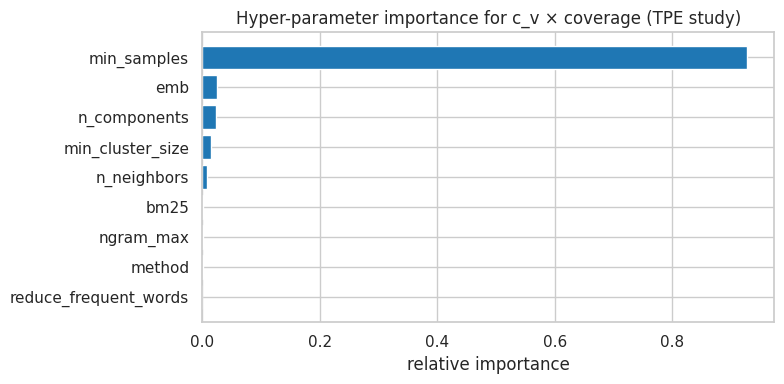

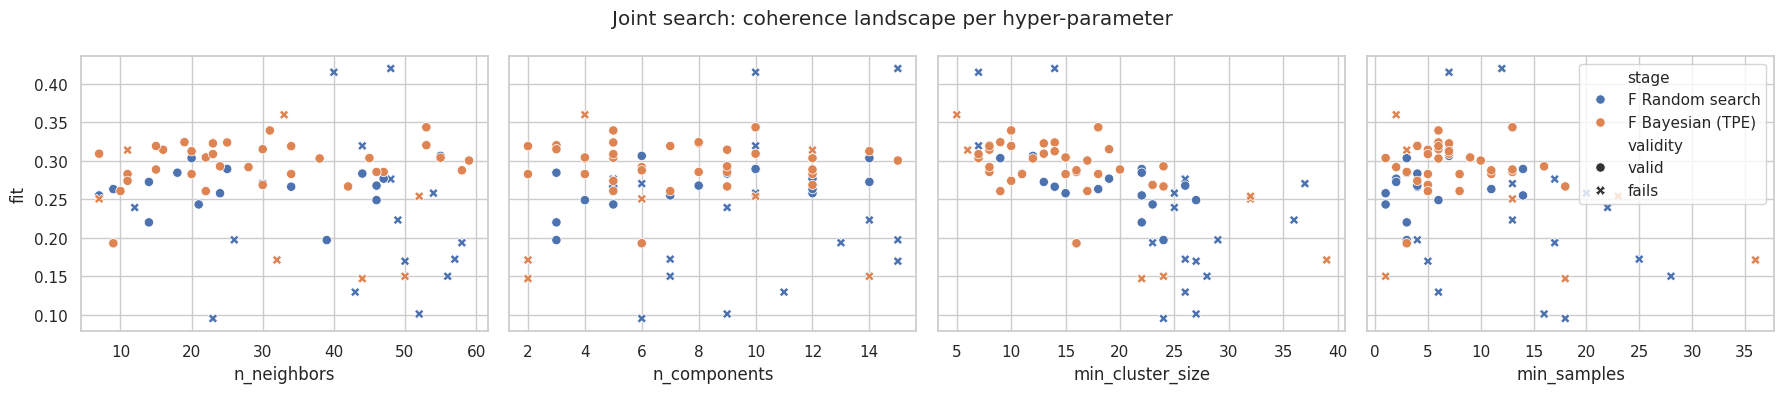

In [25]:
def best_so_far(vals):
    out, cur = [], -np.inf
    for v in vals:
        if not np.isnan(v):
            cur = max(cur, v)
        out.append(cur if np.isfinite(cur) else np.nan)
    return out

curves = {
    "Coordinate descent (stages A-E)": [r["score"] for r in LOG if r["stage"][0] in "ABCDE"],
    "Random search":                   [r["score"] for r in LOG if r["stage"] == "F Random search"],
    "Bayesian optimisation (TPE)":     [r["score"] for r in LOG if r["stage"] == "F Bayesian (TPE)"],
}
fig, ax = plt.subplots(figsize=(12, 5))
for (name, vals), col in zip(curves.items(), ["tab:orange", "tab:gray", "tab:blue"]):
    x = np.arange(1, len(vals) + 1)
    ax.scatter(x, vals, s=14, alpha=0.35, color=col)
    ax.plot(x, best_so_far(vals), lw=2.5, color=col, label=f"{name} (best {np.nanmax(vals):.3f})")
ax.axhline(baseline["fit"], ls="--", color="black", alpha=0.6, label=f"original setup ({baseline['fit']:.3f})")
ax.set_xlabel("number of model fits"); ax.set_ylabel("score = c_v × coverage")
ax.set_title("How each optimisation strategy converges (line = best so far, dots = individual fits)")
ax.legend(); plt.tight_layout(); plt.show()

# Which hyper-parameters mattered most (fANOVA on the TPE study)
try:
    imp = optuna.importance.get_param_importances(study_tpe)
    plt.figure(figsize=(8, 4))
    plt.barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="tab:blue")
    plt.xlabel("relative importance"); plt.title("Hyper-parameter importance for c_v × coverage (TPE study)")
    plt.tight_layout(); plt.show()
except Exception as ex:
    print("Importance plot skipped:", ex)

# Coherence landscape of all joint-search trials
f = pd.concat([stage_df("F Random search"), stage_df("F Bayesian (TPE)")]).reset_index(drop=True)
f["validity"] = f["score"].isna().map({True: "fails", False: "valid"})
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, p in zip(axes, ["n_neighbors", "n_components", "min_cluster_size", "min_samples"]):
    sns.scatterplot(data=f, x=p, y="fit", hue="stage", style="validity", ax=ax, s=45)
    leg = ax.get_legend()
    if leg is not None and ax is not axes[-1]:
        leg.remove()
axes[0].set_ylabel("fit")
fig.suptitle("Joint search: coherence landscape per hyper-parameter"); plt.tight_layout(); plt.show()

### Stage G — seed stability of the overall winner

Overall best stage: E Topic reduction
Config: {'emb': 'minilm|cleaned', 'n_neighbors': 50, 'n_components': 5, 'min_cluster_size': 8, 'min_samples': None, 'method': 'eom', 'ngram_max': 2, 'reduce_frequent_words': False, 'bm25': False, 'nr_topics': 11}
fit=0.383  c_v=0.559  coverage=68%  c_npmi=0.030  topics=10  outliers=46%


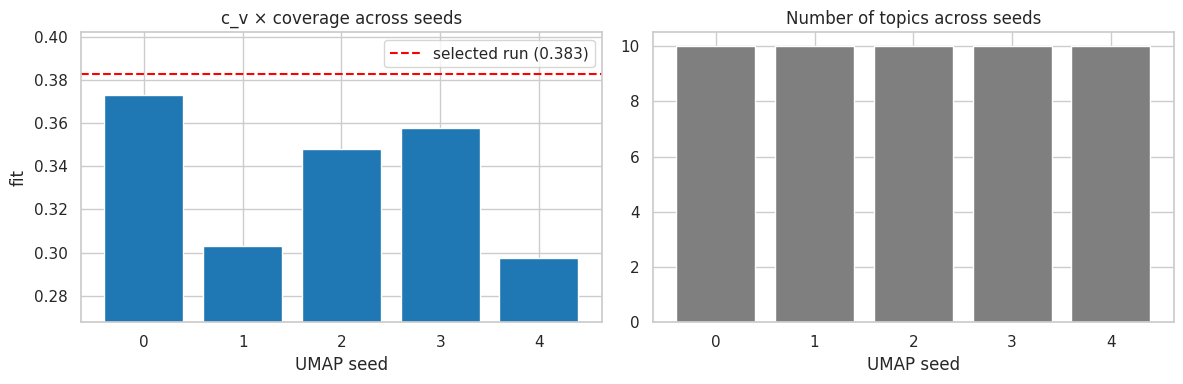

Across seeds: fit mean 0.336 ± 0.034 | coverage mean 63%


In [26]:
overall = best_record()
print("Overall best stage:", overall["stage"])
print("Config:", {k: overall["cfg"][k] for k in BASE_CFG})
print(f"fit={overall['fit']:.3f}  c_v={overall['c_v']:.3f}  coverage={overall['coverage']:.0%}  "
      f"c_npmi={overall['c_npmi']:.3f}  topics={overall['n_topics']}  outliers={overall['outlier_pct']:.0%}")

stab_seeds = [0, 1, 2] if FAST_MODE else [0, 1, 2, 3, 4]
for s in stab_seeds:
    run_config({}, stage="G Stability", base=overall["cfg"], seed=s, verbose=False)
g = stage_df("G Stability")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(g["seed"].astype(str), g["fit"], color="tab:blue")
axes[0].axhline(overall["fit"], color="red", ls="--", label=f"selected run ({overall['fit']:.3f})")
axes[0].set_ylim(min(g["fit"].min(), overall["fit"]) * 0.9, max(g["fit"].max(), overall["fit"]) * 1.05)
axes[0].set_xlabel("UMAP seed"); axes[0].set_ylabel("fit"); axes[0].legend(); axes[0].set_title("c_v × coverage across seeds")
axes[1].bar(g["seed"].astype(str), g["n_topics"], color="tab:gray")
axes[1].set_xlabel("UMAP seed"); axes[1].set_title("Number of topics across seeds")
plt.tight_layout(); plt.show()
print(f"Across seeds: fit mean {g['fit'].mean():.3f} ± {g['fit'].std():.3f} | "
      f"coverage mean {g['coverage'].mean():.0%}")

### Optimisation summary

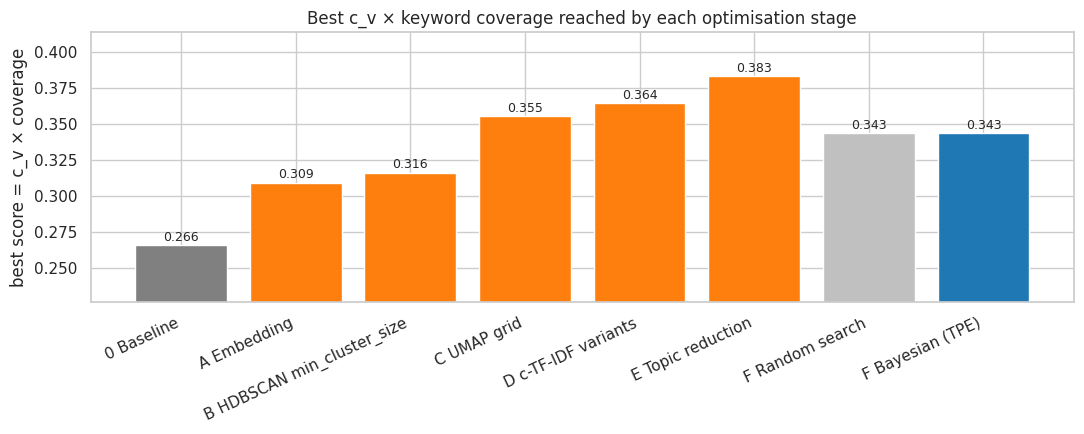

,stage,best fit,c_v,coverage,c_npmi,topics,outliers,diversity
0,0 Baseline,0.266,0.483,0.550,-0.041,10,0.345,0.970
1,A Embedding,0.309,0.476,0.650,-0.032,14,0.338,0.900
2,B HDBSCAN min_cluster_size,0.316,0.485,0.651,-0.009,17,0.245,0.933
3,C UMAP grid,0.355,0.523,0.678,0.008,11,0.458,0.962
4,D c-TF-IDF variants,0.364,0.532,0.685,0.025,11,0.458,0.959
5,E Topic reduction,0.383,0.559,0.685,0.030,10,0.458,0.966
6,F Random search,0.343,0.597,0.575,0.114,9,0.468,0.939
7,F Bayesian (TPE),0.343,0.597,0.575,0.114,9,0.468,0.939


,stage,emb,n_neighbors,n_components,min_cluster_size,min_samples,method,ngram_max,reduce_frequent_words,bm25,nr_topics,fit,c_v,coverage,c_npmi,n_topics,outlier_pct
45,E Topic reduction,minilm|cleaned,50,5,8,NaN,eom,2,False,False,11,0.383,0.559,0.685,0.030,10,0.458
44,E Topic reduction,minilm|cleaned,50,5,8,NaN,eom,2,False,False,10,0.369,0.539,0.685,0.018,9,0.458
32,D c-TF-IDF variants,minilm|cleaned,50,5,8,NaN,eom,2,False,False,None,0.364,0.532,0.685,0.025,11,0.458
40,E Topic reduction,minilm|cleaned,50,5,8,NaN,eom,2,False,False,auto,0.364,0.532,0.685,0.025,11,0.458
39,E Topic reduction,minilm|cleaned,50,5,8,NaN,eom,2,False,False,None,0.364,0.532,0.685,0.025,11,0.458
34,D c-TF-IDF variants,minilm|cleaned,50,5,8,NaN,eom,2,False,True,None,0.364,0.532,0.685,0.025,11,0.458
43,E Topic reduction,minilm|cleaned,50,5,8,NaN,eom,2,False,False,9,0.359,0.542,0.661,0.023,8,0.458
33,D c-TF-IDF variants,minilm|cleaned,50,5,8,NaN,eom,1,False,True,None,0.355,0.523,0.678,0.008,11,0.458
29,C UMAP grid,minilm|cleaned,50,5,8,NaN,eom,1,False,False,None,0.355,0.523,0.678,0.008,11,0.458
31,D c-TF-IDF variants,minilm|cleaned,50,5,8,NaN,eom,1,False,False,None,0.355,0.523,0.678,0.008,11,0.458


In [27]:
stages = ["0 Baseline", "A Embedding", "B HDBSCAN min_cluster_size", "C UMAP grid", "D c-TF-IDF variants",
          "E Topic reduction", "F Random search", "F Bayesian (TPE)"]
summ = []
for s in stages:
    try:
        r = best_record([s])
        summ.append({"stage": s, "best fit": r["fit"], "c_v": r["c_v"], "coverage": r["coverage"],
                     "c_npmi": r["c_npmi"], "topics": r["n_topics"],
                     "outliers": r["outlier_pct"], "diversity": r["diversity"]})
    except RuntimeError:
        pass
summ = pd.DataFrame(summ)
fig, ax = plt.subplots(figsize=(11, 4.5))
stage_color = lambda s: "gray" if s.startswith("0") else ("tab:blue" if "TPE" in s else ("silver" if "Random" in s else "tab:orange"))
bars = ax.bar(summ["stage"], summ["best fit"], color=[stage_color(s) for s in summ["stage"]])
for b_, v in zip(bars, summ["best fit"]):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(summ["best fit"].min() * 0.85, summ["best fit"].max() * 1.08)
ax.set_ylabel("best score = c_v × coverage"); ax.set_title("Best c_v × keyword coverage reached by each optimisation stage")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()
display(summ.round(3))

log_df = pd.DataFrame([{k: v for k, v in r.items() if k != "cfg"} for r in LOG])
log_df.to_csv("/content/bertopic_optimisation_log.csv", index=False)
display(log_df[log_df["stage"] != "G Stability"].sort_values("score", ascending=False)
        .head(10)[["stage", "emb", "n_neighbors", "n_components", "min_cluster_size", "min_samples", "method",
                   "ngram_max", "reduce_frequent_words", "bm25", "nr_topics", "fit", "c_v", "coverage", "c_npmi", "n_topics", "outlier_pct"]]
        .round(3))

## 13. Final Model & Readable Topics (no LLM API)
1. Refit the winning configuration and add two extra keyword representations (**KeyBERTInspired**, **MaximalMarginalRelevance**); keep whichever has the best **c_v × coverage** for display.
2. Score every Biden sentence with Twitter-RoBERTa to get each topic's sentiment mix.
3. For each topic, pick example sentences that **contain the topic's keywords** (weighted by keyword rank), using closeness to the topic centre only as a tie-breaker. In v3 the examples were picked purely by closeness to the centre, which in a mixed cluster returns the most generic "Sleepy Joe..." sentence — that is why the summaries did not match the keywords.
4. **`google/flan-t5-large`** writes a neutral summary and a 2–4 word title **given the keywords**. Both are checked: the summary must mention a keyword and every word of the title must come from the keywords or the example sentences; otherwise a keyword-based title / extractive summary is used. This removes hallucinated titles such as "Amnesty international 's amn".

Final model: 10 topics | fit=0.383 | c_v=0.559 | coverage=68% | c_npmi=0.030 | outliers=46%


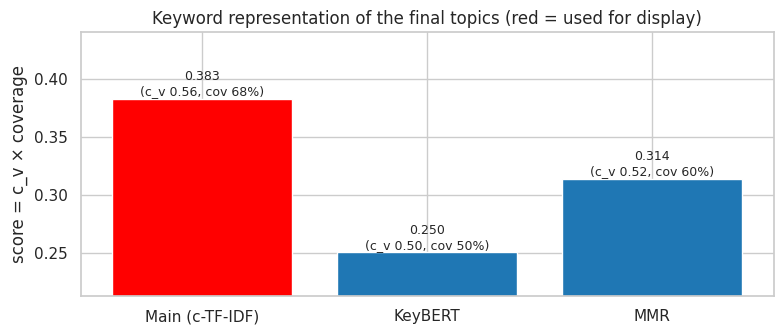

In [28]:
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance

FINAL_CFG = dict(overall["cfg"])
final_model = build_model(
    FINAL_CFG, seed=overall["seed"],
    representation_model={"KeyBERT": KeyBERTInspired(), "MMR": MaximalMarginalRelevance(diversity=0.3)},
    embedding_model=ST[FINAL_CFG["emb"].split("|")[0]])
final_model.fit(DOCS, embeddings=EMB[FINAL_CFG["emb"]])
final_metrics = evaluate(final_model)
print(f"Final model: {final_metrics['n_topics']} topics | fit={final_metrics['fit']:.3f} | c_v={final_metrics['c_v']:.3f} "
      f"| coverage={final_metrics['coverage']:.0%} | c_npmi={final_metrics['c_npmi']:.3f} "
      f"| outliers={final_metrics['outlier_pct']:.0%}")

rep_rows = []
for asp in ["Main (c-TF-IDF)", "KeyBERT", "MMR"]:
    m = evaluate(final_model, None if asp.startswith("Main") else asp)
    rep_rows.append({"representation": asp, "fit": m["fit"], "c_v": m["c_v"], "coverage": m["coverage"],
                     "c_npmi": m["c_npmi"], "diversity": m["diversity"]})
rep_df = pd.DataFrame(rep_rows)
BEST_ASPECT = rep_df.loc[rep_df["fit"].idxmax(), "representation"]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(rep_df["representation"], rep_df["fit"],
       color=["red" if r == BEST_ASPECT else "tab:blue" for r in rep_df["representation"]])
for i, (v, cv_, cov) in enumerate(zip(rep_df["fit"], rep_df["c_v"], rep_df["coverage"])):
    ax.text(i, v + 0.003, f"{v:.3f}\n(c_v {cv_:.2f}, cov {cov:.0%})", ha="center", fontsize=9)
ax.set_ylim(rep_df["fit"].min() * 0.85, rep_df["fit"].max() * 1.15)
ax.set_ylabel("score = c_v × coverage"); ax.set_title("Keyword representation of the final topics (red = used for display)")
plt.tight_layout(); plt.show()

In [29]:
info = final_model.get_document_info(DOCS)
info["Sentence"] = DOCS_ORIG
info["Date"] = DOCS_DATES
info["Sentiment"], _ = roberta_sentiment(DOCS_ORIG)

KW = topic_word_lists(final_model, None if BEST_ASPECT.startswith("Main") else BEST_ASPECT, topn=10)
TOPIC_IDS = sorted(KW)
CV_TOPIC = {t: CV.score_topic(w, "c_v") for t, w in KW.items()}
COV_TOPIC = keyword_coverage(final_model, KW)
TOPIC_ARR = info["Topic"].values
E_FINAL = EMB[FINAL_CFG["emb"]]

def kw_score(i, t, topn=10):
    """How strongly sentence i matches topic t's keywords (higher-ranked keywords count more)."""
    ws = KW[t][:topn]
    return sum((topn - r) / topn for r, w in enumerate(ws) if w in DOC_TOKENS[i])

def examples_for(t, k=4, require_keyword=True):
    """Sentences that contain the topic's keywords first; closeness to the topic centre only breaks ties."""
    idx = np.where(TOPIC_ARR == t)[0]
    if len(idx) == 0:
        return []
    cen = E_FINAL[idx].mean(axis=0)
    cen = cen / (np.linalg.norm(cen) + 1e-12)
    sim = E_FINAL[idx] @ cen
    kws = np.array([kw_score(i, t) for i in idx])
    order = idx[np.lexsort((-sim, -kws))]            # primary: keyword score, secondary: centrality
    kw_of = dict(zip(idx, kws))
    seen, out = set(), []
    for i in order:
        if require_keyword and kw_of[i] <= 0:
            break
        s = DOCS_ORIG[i]
        key = s.lower()[:60]
        if key in seen or not (6 <= len(s.split()) <= 60):
            continue
        seen.add(key)
        out.append(s)
        if len(out) == k:
            break
    if not out and require_keyword:
        return examples_for(t, k, require_keyword=False)
    return out or [DOCS_ORIG[i] for i in order[:k]]


In [30]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

lab_tok = AutoTokenizer.from_pretrained(LABEL_MODEL)
lab_model = AutoModelForSeq2SeqLM.from_pretrained(LABEL_MODEL).to(TORCH_DEVICE).eval()

def shorten(s, n=35):
    w = s.split()
    return " ".join(w[:n]) + (" ..." if len(w) > n else "")

def generate(prompt, max_new=16, min_new=1):
    inputs = lab_tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(TORCH_DEVICE)
    with torch.no_grad():
        out = lab_model.generate(**inputs, max_new_tokens=max_new, min_new_tokens=min_new, num_beams=4,
                                 no_repeat_ngram_size=3, early_stopping=True)
    return lab_tok.decode(out[0], skip_special_tokens=True).strip()

# ---- validation helpers: generated text must be grounded in the topic's keywords -----------------
def _words(text):
    return re.findall(r"[a-z]+", text.lower())

def _match(tok, kw):
    """Loose stem match: "tax"~"taxes", "vote"~"voting", "violent"~"violence"."""
    n = len(os.path.commonprefix([tok, kw]))
    return n >= max(3, min(len(tok), len(kw)) - 2)

def mentions_keyword(text, keywords, n=6):
    toks = _words(text)
    return any(_match(tk, k) for k in keywords[:n] for tk in toks)

KEEP_CAPS = {"I", "Biden", "Joe", "America", "American", "Americans", "China", "Chinese", "Obama",
             "Democrats", "Democrat", "Republicans", "Kamala", "Harris", "Congress", "Mexico"}

def _as_trump_says(s):
    s = s.strip().strip('"')
    if s.lower().startswith("trump"):
        return s
    first = re.sub(r"\W.*", "", s.split()[0]) if s.split() else ""
    if first not in KEEP_CAPS and not first.isupper():
        s = s[:1].lower() + s[1:]
    return "Trump says " + s

def summarize_topic(examples, keywords):
    for exs in (examples[:6], examples[:3]):     # second try with only the strongest examples
        prompt = ("These sentences come from Donald Trump's rally speeches. They all belong to one topic "
                  f"whose key words are: {', '.join(keywords[:6])}.\n"
                  "In one or two neutral sentences, describe what Trump says about Biden on this topic, "
                  "using the key words. Start with 'Trump says'.\n\n"
                  "Sentences:\n" + "\n".join(f"- {shorten(s)}" for s in exs) + "\n\nDescription:")
        s = generate(prompt, max_new=70, min_new=12)
        if len(s.split()) >= 5 and mentions_keyword(s, keywords):
            s = _as_trump_says(s)
            return s if s.endswith((".", "!", "?")) else s + "."
    # fallback: the most keyword-rich example sentence itself (extractive, always on-topic)
    return "Trump says: " + shorten(examples[0], 30) if examples else "Trump says: (no example)"

TITLE_SHOTS = ("Write a short topic title of 2 to 4 words for a group of political speech sentences. "
               "Use the keywords.\n\n"
               "Summary: Trump says the Space Force will keep America ahead of other countries in space.\n"
               "Keywords: space, force, rockets, military\nTitle: Space Force and military\n\n"
               "Summary: Trump says coal miners lost their jobs because of strict energy rules.\n"
               "Keywords: coal, miners, energy, regulations\nTitle: Coal and energy jobs\n\n")

TITLE_DROP = {"trump", "says", "biden", "joe", "sleepy", "topic", "title"}

def keyword_title(t, n=3):
    """Deterministic fallback: the top c-TF-IDF terms (bigrams kept), without near-duplicates."""
    terms = [w for w, _ in final_model.get_topic(t) if w]
    picked = []
    for w in terms:
        if any(w in p or p in w for p in picked):
            continue
        picked.append(w)
        if len(picked) == n:
            break
    return ", ".join(picked).capitalize() if picked else f"Topic {t}"

def title_ok(title, keywords, examples):
    content = [w for w in _words(title) if len(w) > 2 and w not in ENGLISH_STOP_WORDS]
    if not (1 <= len(content) <= 5):
        return False
    vocab = set(_words(" ".join(examples + keywords)))
    grounded = all(any(_match(v, w) or _match(w, v) for v in vocab) for w in content)
    return grounded and mentions_keyword(title, keywords, n=8)

def title_topic(t, summary, keywords, examples):
    prompt = TITLE_SHOTS + f"Summary: {summary}\nKeywords: {', '.join(keywords[:6])}\nTitle:"
    lab = generate(prompt, max_new=10).split("\n")[0]
    lab = re.sub(r"^(title|topic)\s*[:\-]\s*", "", lab, flags=re.I).strip().strip('.:"\'')
    lab = " ".join(w for w in lab.split() if w.lower().strip("'s") not in TITLE_DROP)
    if not title_ok(lab, keywords, examples):
        return keyword_title(t), "keywords"
    return lab[:1].upper() + lab[1:], "flan-t5"

LABELS, SUMMARIES, EXAMPLES, used = {}, {}, {}, set()
for t in TOPIC_IDS:
    EXAMPLES[t] = examples_for(t, k=7)
    SUMMARIES[t] = summarize_topic(EXAMPLES[t], KW[t])
    lab, src_ = title_topic(t, SUMMARIES[t], KW[t], EXAMPLES[t])
    if lab.lower() in used:
        lab = f"{lab} ({KW[t][0]})"
    used.add(lab.lower())
    LABELS[t] = lab
    print(f"Topic {t}: {lab}   [title from {src_}, keyword coverage {COV_TOPIC.get(t, np.nan):.0%}]")
    print(textwrap.fill(SUMMARIES[t], 105, initial_indent="   ", subsequent_indent="   "))
    print(f"   keywords: {', '.join(KW[t][:6])}\n")

final_model.set_topic_labels({**{t: f"{t}. {LABELS[t]}" for t in TOPIC_IDS}, -1: "Outliers"})


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Topic 0: Left, police, radical   [title from keywords, keyword coverage 66%]
   Trump says Biden will always do whatever the radical left demands and if elected, his radical
   supporters won't just be causing mayhem on the streets.
   keywords: left, police, radical, far, law, enforcement

Topic 1: Came a lot of nice guys   [title from flan-t5, keyword coverage 35%]
   Trump says sleepy Joe Biden, not a nice guy, by the way.
   keywords: nice, came, great, lot, mean, fine

Topic 2: Jobs, supported, american   [title from keywords, keyword coverage 71%]
   Trump says Joe Biden devoted his entire career to offshoring Wisconsin jobs, outsourcing your
   factories, throwing open your borders, dragging us into endless ridiculous foreign wars, and
   surrendering our children's future to countries like China.
   keywords: jobs, supported, american, foreign, wars, endless

Topic 3: Years, spent, period   [title from keywords, keyword coverage 93%]
   Trump says we spent the last four years, 

In [31]:
rows = []
for t in TOPIC_IDS:
    sub = info[info["Topic"] == t]
    shares = sub["Sentiment"].value_counts(normalize=True)
    ex = examples_for(t, 1)
    rows.append({"Topic": t, "Label": LABELS[t], "Size": len(sub), "c_v": CV_TOPIC[t],
                 "Coverage": COV_TOPIC.get(t, np.nan),
                 "Negative": shares.get("negative", 0.0), "Neutral": shares.get("neutral", 0.0),
                 "Positive": shares.get("positive", 0.0), "Keywords": ", ".join(KW[t][:8]), "Summary": SUMMARIES[t],
                 "Example": ex[0] if ex else ""})
topic_summary = pd.DataFrame(rows).sort_values("Size", ascending=False).reset_index(drop=True)
topic_summary.to_csv("/content/topic_summary.csv", index=False)
display(topic_summary.drop(columns=["Example", "Summary"]).round(3))
# ---- sanity check: do the keywords really describe the sentences of each topic? ---------------
print("\nKeyword coverage per topic (share of the topic's sentences containing >=1 of its top "
      f"{COVERAGE_TOPN} keywords):")
for r in topic_summary.itertuples():
    flag = "   <-- weak topic, read its sentences before trusting the label" if r.Coverage < 0.5 else ""
    print(f"  {r.Topic:>2}. {r.Label[:45]:<45} {r.Coverage:>5.0%}{flag}")
    rng = np.random.default_rng(SEED)
    sample = rng.choice(info.loc[info["Topic"] == r.Topic, "Sentence"].values,
                        size=min(3, r.Size), replace=False)
    for s in sample:
        print("        -", textwrap.shorten(s, 120))


,Topic,Label,Size,c_v,Coverage,Negative,Neutral,Positive,Keywords
0,0,"Left, police, radical",88,0.667,0.659,0.830,0.136,0.034,"left, police, radical, far, law, enforcement, ..."
1,1,Came a lot of nice guys,37,0.380,0.351,0.405,0.459,0.135,"nice, came, great, lot, mean, fine, better, love"
2,2,"Jobs, supported, american",35,0.593,0.714,0.943,0.057,0.000,"jobs, supported, american, foreign, wars, endl..."
3,3,"Years, spent, period",29,0.370,0.931,0.724,0.172,0.103,"years, spent, period, year, horrible, betrayal..."
4,4,"Tax, destroy, ban",28,0.708,0.607,0.786,0.214,0.000,"tax, destroy, ban, impose, american, energy, e..."
5,5,"Vote, debate, personal",21,0.312,1.000,0.238,0.714,0.048,"vote, debate, personal, rally, nomination, sin..."
6,6,Son gets thrown out of,18,0.530,0.778,0.667,0.278,0.056,"son, dollars, thrown, money, energy, deal, abs..."
7,7,"Pandemic, record, recovery",14,0.860,0.500,0.857,0.143,0.000,"pandemic, record, recovery, decide, prosperity..."
8,8,"Travel, camp, communities",13,0.508,0.692,0.846,0.154,0.000,"travel, camp, terminate, communities, ban, hys..."
9,9,"Wins, mob, power",9,0.663,1.000,0.556,0.444,0.000,"wins, mob, win, power"



Keyword coverage per topic (share of the topic's sentences containing >=1 of its top 5 keywords):
   0. Left, police, radical                           66%
        - These are far-left lunatics that Biden selects to staff has government.
        - If Joe gets in, the radical left will shut down the Iron Range forever.
        - If Joe Biden is elected, far-left lunatics won't just be running failed Democrat city.
   1. Came a lot of nice guys                         35%   <-- weak topic, read its sentences before trusting the label
        - I kept hoping, but I think honestly, I think that sleepy Joe, crazy Bernie, I don't even want to put Buttigieg in.
        - If Sleepy Joe came here, if he had -- I really mean this, you know the little circles he fills and he can't get [...]
        - Please, please, Joe, you're doing fine, Joe you're doing fine, you're doing fine.
   2. Jobs, supported, american                       71%
        - Joe Biden supported the disastrous Trans-Pacific

### 13.1 Topic summaries in plain sentences
Each topic with its short title and the neutral summary written above, so it can be read as a description rather than a list of words.

In [32]:
import html as html_lib
from IPython.display import HTML

cards = []
for r in topic_summary.itertuples():
    cards.append(f"""
    <div style="border:1px solid #ccc;border-left:6px solid #c0392b;border-radius:6px;padding:10px 14px;margin:8px 0;">
      <div style="font-size:15px;font-weight:bold;">Topic {r.Topic}: {html_lib.escape(r.Label)}</div>
      <div style="font-size:12px;color:#666;margin:2px 0 6px;">{r.Size} sentences &nbsp;|&nbsp;
        {r.Negative:.0%} negative, {r.Neutral:.0%} neutral, {r.Positive:.0%} positive &nbsp;|&nbsp;
        keyword coverage {r.Coverage:.0%}</div>
      <div style="font-size:14px;line-height:1.45;">{html_lib.escape(r.Summary)}</div>
      <div style="font-size:12px;color:#777;margin-top:6px;">Keywords: {html_lib.escape(r.Keywords)}</div>
    </div>""")
display(HTML("".join(cards)))

### 13.2 Topic cards (static, readable)

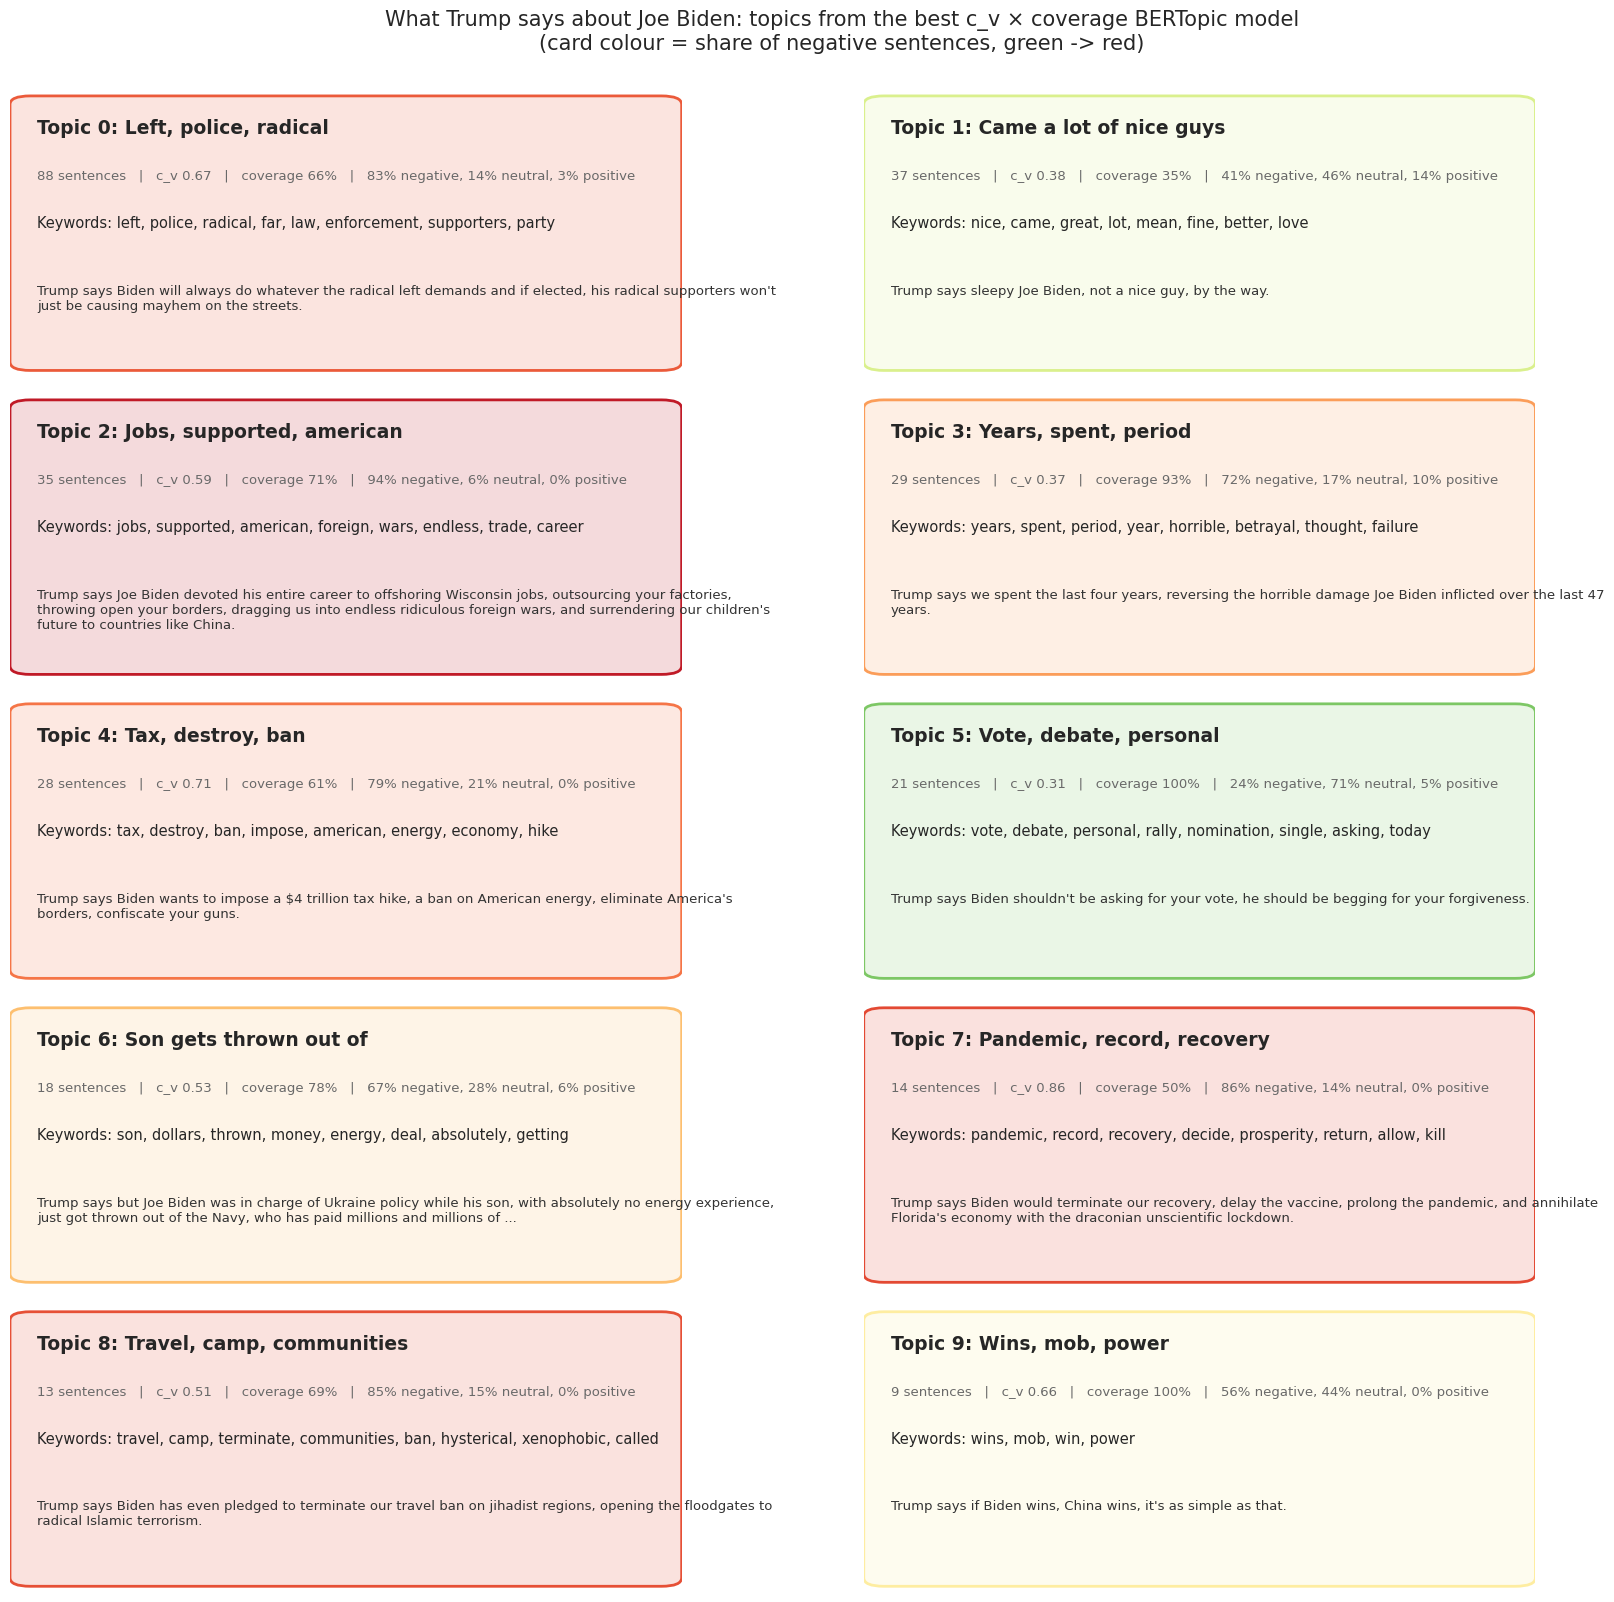

In [33]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgba

cmap = plt.cm.RdYlGn_r
ncols = 2
nrows = math.ceil(len(topic_summary) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.axis("off")
for ax, r in zip(axes, topic_summary.itertuples()):
    ax.add_patch(FancyBboxPatch((0.01, 0.03), 0.98, 0.94, boxstyle="round,pad=0.01,rounding_size=0.03",
                                transform=ax.transAxes, facecolor=to_rgba(cmap(r.Negative), 0.16),
                                edgecolor=cmap(r.Negative), lw=2))
    ax.text(0.04, 0.90, textwrap.shorten(f"Topic {r.Topic}: {r.Label}", 70), transform=ax.transAxes,
            fontsize=13.5, weight="bold", va="top")
    ax.text(0.04, 0.72, f"{r.Size} sentences   |   c_v {r.c_v:.2f}   |   coverage {r.Coverage:.0%}   |   "
                        f"{r.Negative:.0%} negative, {r.Neutral:.0%} neutral, {r.Positive:.0%} positive",
            transform=ax.transAxes, fontsize=9.5, color="dimgray", va="top")
    ax.text(0.04, 0.56, textwrap.fill("Keywords: " + r.Keywords, 95), transform=ax.transAxes, fontsize=10.5, va="top")
    ax.text(0.04, 0.32, textwrap.fill(textwrap.shorten(r.Summary, 260), 110),
            transform=ax.transAxes, fontsize=9.5, va="top", color="#333333")
fig.suptitle("What Trump says about Joe Biden: topics from the best c_v × coverage BERTopic model\n"
             "(card colour = share of negative sentences, green -> red)", fontsize=15, y=1.0)
plt.tight_layout(); plt.show()

### 13.3 Topic overview: size, coherence and sentiment

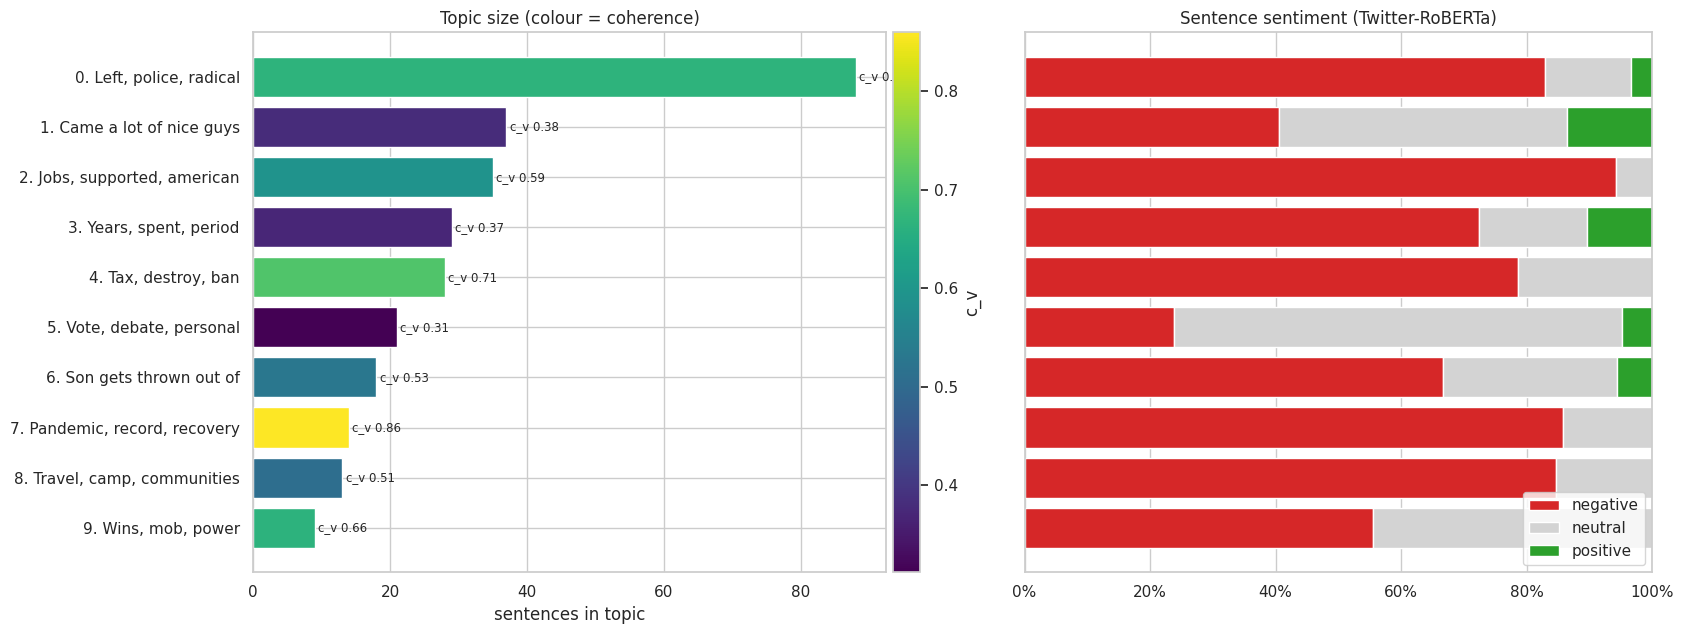

In [34]:
ts = topic_summary.sort_values("Size")
ylabels = [textwrap.shorten(f"{t}. {l}", 45) for t, l in zip(ts["Topic"], ts["Label"])]
fig, axes = plt.subplots(1, 2, figsize=(17, 0.45 * len(ts) + 2), sharey=True, gridspec_kw={"width_ratios": [1.2, 1]})
norm = plt.Normalize(ts["c_v"].min(), ts["c_v"].max())
axes[0].barh(ylabels, ts["Size"], color=plt.cm.viridis(norm(ts["c_v"])))
for y_, (s, v) in enumerate(zip(ts["Size"], ts["c_v"])):
    axes[0].text(s + 0.5, y_, f"c_v {v:.2f}", va="center", fontsize=8.5)
axes[0].set_xlabel("sentences in topic"); axes[0].set_title("Topic size (colour = coherence)")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm); fig.colorbar(sm, ax=axes[0], label="c_v", pad=0.01)
left = np.zeros(len(ts))
for col, color in (("Negative", "tab:red"), ("Neutral", "lightgray"), ("Positive", "tab:green")):
    axes[1].barh(ylabels, ts[col], left=left, color=color, label=col.lower()); left += ts[col].values
axes[1].set_xlim(0, 1); axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].set_title("Sentence sentiment (Twitter-RoBERTa)"); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

### 13.4 Interactive BERTopic views (with the generated labels and summaries)

In [35]:
import plotly.graph_objects as go

def safe_show(fn, name):
    try:
        fn().show()
    except Exception as ex:
        print(f"{name} skipped: {ex}")

def wrap(s, n=75):
    return "<br>".join(textwrap.wrap(s, n))

# 1) topic overview: title + readable summary next to each topic's size bar
def _overview():
    ts = topic_summary.sort_values("Size")
    names = [f"{t}. {l}" for t, l in zip(ts["Topic"], ts["Label"])]
    max_lines = max(len(textwrap.wrap(s, 75)) for s in ts["Summary"]) + 1
    fig = go.Figure(go.Bar(
        x=ts["Size"], y=names, orientation="h",
        marker=dict(color=ts["Negative"], colorscale="RdYlGn_r", cmin=0, cmax=1,
                    colorbar=dict(title="share<br>negative", tickformat=".0%")),
        text=[f"{s} sentences · {n:.0%} negative · {c:.0%} on-keyword"
              for s, n, c in zip(ts["Size"], ts["Negative"], ts["Coverage"])],
        textposition="auto",
        hovertext=[wrap(s) + "<br><br><i>e.g. " + wrap(textwrap.shorten(e, 160)) + "</i>"
                   for s, e in zip(ts["Summary"], ts["Example"])], hoverinfo="text"))
    for name, t, l, s in zip(names, ts["Topic"], ts["Label"], ts["Summary"]):
        fig.add_annotation(x=0, xref="paper", y=name, yref="y", xanchor="left", align="left",
                           showarrow=False, font=dict(size=12),
                           text=f"<b>{t}. {l}</b><br>{wrap(s)}")
    fig.update_layout(title="What each topic is about", width=1250,
                      height=len(ts) * (max_lines * 19 + 30) + 140,
                      xaxis=dict(domain=[0.56, 1], title="sentences in topic"),
                      yaxis=dict(showticklabels=False), margin=dict(l=20, r=20))
    return fig
safe_show(_overview, "Topic overview")

# 2d projection just for the document map
reduced_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric="cosine",
                  random_state=SEED).fit_transform(EMB[FINAL_CFG["emb"]])
safe_show(lambda: final_model.visualize_documents(DOCS_ORIG, reduced_embeddings=reduced_2d, custom_labels=True,
                                                  title="Biden sentences by topic (hover to read)"), "Document map")

safe_show(lambda: final_model.visualize_hierarchy(custom_labels=True, title="Topic hierarchy"), "Hierarchy")

# topics over time: sentences per rally in each quarter, so busy campaign periods don't dominate
def _tot():
    d = info[info["Topic"] != -1].copy()
    d["Quarter"] = pd.to_datetime(d["Date"]).dt.to_period("Q")
    rallies_q = df["Date_parsed"].dt.to_period("Q").value_counts().sort_index()
    all_q = pd.period_range(rallies_q.index.min(), rallies_q.index.max(), freq="Q")
    counts = d.groupby(["Quarter", "Topic"]).size().unstack(fill_value=0).reindex(all_q, fill_value=0)
    n_rallies = rallies_q.reindex(all_q)
    per_rally = counts.div(n_rallies, axis=0)          # stays empty where there were no rallies
    x = [f"{q.year} Q{q.quarter}" for q in all_q]
    fig = go.Figure()
    for t in topic_summary["Topic"]:
        name = f"{t}. {LABELS[t]}"
        y = per_rally[t] if t in per_rally else pd.Series(np.nan, index=all_q)
        hover = [f"<b>{name}</b><br>{xq}: {v:.2f} sentences per rally ({int(counts.at[q, t]) if t in counts else 0} sentences, "
                 f"{int(n) if pd.notna(n) else 0} rallies)<br><br>{wrap(SUMMARIES[t], 70)}"
                 if pd.notna(v) else f"{xq}: no rallies" for xq, q, v, n in zip(x, all_q, y, n_rallies)]
        fig.add_trace(go.Scatter(x=x, y=y, mode="lines+markers", name=name, connectgaps=False,
                                 hovertext=hover, hoverinfo="text"))
    fig.update_layout(title="Topics over time (Biden sentences per rally, by quarter)",
                      xaxis_title="quarter", yaxis_title="sentences per rally",
                      legend_title_text="Topic", width=1250, height=480)
    return fig

if all(pd.notna(d) for d in DOCS_DATES):
    safe_show(_tot, "Topics over time")
else:
    print("Topics over time skipped: some rally dates could not be parsed.")